# Big O Notation

Describes computational complexity of an algorithm. The computational complexity is split into two parts: time complexity and space complexity. 

The Time complexity of an algorithm is the amount of time the algorithm needs to run relative to the input size. 
As the input grows how much longer does the algorithm take to complete

The Space complexity of an algorithm is the amount of memory used by the algorithm relative to the input size.
as the input size grows how much more memory does the algorithm use.


The point of complexity is to analyze the algorithm as the size of theinput changes. We consider the complexity as the variables tend to infinity. Which is why we ignore all the terms except the most powerful one. $O(2^n+n^2−500n)=O(2^n)$ Becasue as n -> inf 2^n becomes so large the other terms are effectively zero in comparison.

The best complexity possible is O(1) constant time or constant space. It means the algorithm always uses the same amount of resources regardless of the input. This doesn't always mean the algorithm is fasta as O(50000000) = O(1) It just means runtime is independent of time.

We alwasys choose the worst case scenario to represent complexity.

for loop inside for loop is O(nxn), two seperate for loops is O(n+M)

logarithmic time, O (logn) is extremely fast, a common time complexity is O(nlogn) which is reasonable fast for most problems. Typically the base of logarithm will be 2 This means that if your input is size n, then the algorithm will before x operationss where $2^x = n$.The base doens't really matter since all logarithms are related by a constant base factor. O(logn) means that somewhere in your algorithm, the input is being reduced by a percentage at every step. A good example of this is binary search. as teh search space reduces bya factor of a half every iteration.

### Recursion 
is where a fucntion calls itself, any iterative ,for loop etc, algorithm can be written recursively. 

Recurrence relation is an equation that connect the terms together. requires base cases

This is the most common use of recursion - you have your recursive function return the answer to the problem you're trying to solve for a given input.


# Arrays and Strings

In terms of algorithm problems, arrays (1D) and strings are very similar they both **represent an ordered group of elements**. Most algorithm problems will include either an array or string as part of the input, so it's important to be comfortable with the baic operations and to learn the most common patterns.

Array can mean something different between languages. For example python primarily uses lists instead of arrays whihc are lenient. Initialisation of arrays in python is arr = [] and you dont need to worry abotu the type of data you store whereas in C++ requires you to specify the size and data type of the array during initialization. 


technically an array can't be resized, a dynamic array or list can be. we only discuss dynamic arrays/ lists which we jsut say array for 

Similarly strings are implemented differently between languages. In Python, they are immutable.

Mutable: a type of data that can be changed. 

Immutable a type of data that cannot be changed, if you want to change something that is immutable you will need to recreate the entire thing.


So if we wanted to change the c into a d for the following we could easily do 


In [9]:
arr = ["a","b","c"]
arr[2] = "d"
print(arr)
s = "abc"
s[2] ="d"

['a', 'b', 'd']


TypeError: 'str' object does not support item assignment

This is not a big deal with small strings but with strings of 100,000 characters it is problematic it would be O(N) to make a new stirng

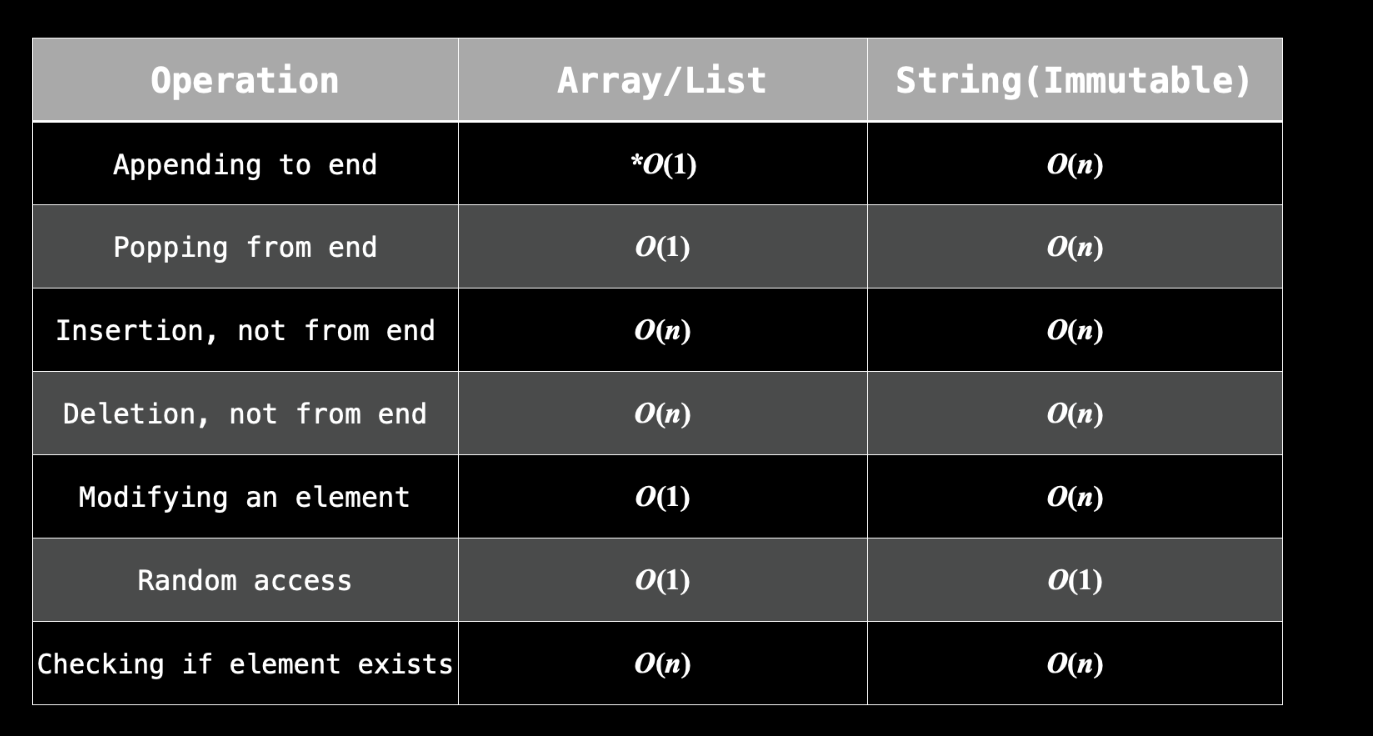

# Two Pointers

Two pointers is an extremely common technique used to solve array and string problems. It involves havign two integer variables that both move along an iterable. In this article , we are focusing on arrays and strings. This means we will have two integers usually named something like i and j, or left and right which each represent an index of the array or string.

There are several ways to implement two pointers.

Start the pointers at the edges of the input. Move them towards each other until they meet.

Convering this idea into instructions:
1) start one pointer at the first index - and the other pointer at the last index input.length - 1 because of zero indexing

2) Use a while loop until the pointers are equal to each other.

3) At each iteration of the loop, move the pointers towards each other. This means either increment the pointer that started at the first index, decrement the pointer that started at the last index, or both. Deciding which pointers to move will depend on the problem that we are trying to solve.

The strength of this technique is we will never have more than O(n) iterations for the while loop because the pointers start n away from each other and move at least one step closer in every iteration. Therefore, if we can keep the work inside each iteration at O(1), this technique will result in a linear runtime, which is usually the best possible runtime. 

**Example 1** one given a string s, return true if it is a palindrome , false otherwise

In [ ]:
def check_if_palindrom(s):
    left = 0
    right = len(s) - 1

    while left < right:
        if s[left] != s[right]:
            return False
        left += 1
        right -= 1

    return True

check_if_palindrom('hannah')

Notice that if the input was an array of characters instead of a string, the algorithm wouldn't change. The two pointers technique works as the index variables are moving along some abstract iterable. 

The algorithm is very efficient as not only dows it run in O(n) it also uses O(1) space as we only return truw or false. the while loop iterations cost O(1) each

 **Example 2** Given a sorted array of unique integers and a target integer return true if there exists a pair of numbers that sum to the target false otherwise

In [ ]:
def check_for_target(nums, target):
    nums.sort()
    left = 0
    right = len(nums) - 1

    while left < right:
        curr = nums[left] + nums[right]
        if curr == target:
            return True
        if curr > target:
            right -= 1
        else:
            left += 1

    return False

In [ ]:
nums = [1, 2, 4, 7, 5, 10, 8, 14, 15]

check_for_target(nums, 28)

### Another way to use two pointers


##### Move along both inputs simultaneously until all elements have been checked

1) Create two pointers, one for each iterable. Each pointer should start at the first index
2) Use a while loop until one of the pointers reaches the end of its iterable.
3) At each iteration of the loop, move the pointers forward. This means incrementing either one of the pointers or both of the pointers. Deciding which pointers to move will depend on the problem we are trying to solve.
4) Because our while loop will stop when one of the pointers reaches the end, the other pointer will not be at the end of its repsective iterable when the loop finishes. Sometimes we need to iterate through all elements if this is the case, you will need to write extra code to ensure both iterables are exhausted.

**Example 3** 

Given two sorted integer arrays arr1 and arr2, return a new array that combines both of them and is also sorted.

In [ ]:
def combine(arr1,arr2):
    ans = []
    i = j = 0

    while i < len(arr1) and j < len(arr2):
        if arr1[i] < arr2[j]:
            ans.append(arr1[i])
            i +=1
        else:
            ans.append(arr2[j])
            j +=1

    while i < len(arr1):
        ans.append(arr1[i])
        i += 1

    while j < len(arr1):
        ans.append(arr2[j])
        j += 1

    return ans

In [ ]:
arr1 = [1,3,5,7,9,11]
arr2 = [0,2,4,6,8,10]
combine(arr1, arr2)

**Example 4: is subsequence**

Given two strings s and t, return true if s is a subsequence of t, or false otherwise. 

In [ ]:
def isSubsequence(s,t):
    i = j = 0
    while i < len(s) and j < len(t):
        if s[i] == t[j]:
            i += 1
        j += 1

    return i == len(s)





#### Example Reverse String

Write a function that reverses a string. The input string is given as an array of characters s.


In [ ]:
def reverseString(s):
    left, right = 0, len(s) - 1
    while left < right:
        s[left], s[right] = s[right], s[left] 
        left += 1
        right -= 1
    return s

In [ ]:
reverseString(list('encyclopedia'))

#### Example Squares of a Sorted Array

Given an integer array nums sorted in non-decreasing order return an array of the squares of each number sorted in non - decreasing order.

In [ ]:
def sortedSquares(nums):
    n  = len(nums)
    result = [0] * n
    left = 0
    right = n-1
    for i in range(n-1, -1, -1):
        if abs(nums[left]) < abs(nums[right]):
            square = nums[right]
            right -=1
        else:
            square = nums[left]
            left += 1
        result[i] = square * square

    return result

In [ ]:
arr = [-3, -2, -1, 4, 5, 6]
sortedSquares(arr)

# Sliding Window

Like two pointers sliding windows work the same with arrays and strings, the important thing is taht they're iterables with **ordered** elements. We focus on arrays, however all the logic is identical for strings as well.

Sliding window is another common approach to solving problems related to arrays. A slidign window is actually implemented using two pointers! Before we start, we need to talk about the concept of a subarray.

### Subarrays
Given an array, a subarray is a contiguous (touching, sharing border) section of the array. All the elements must be adjacent to each other in the original array and in their original order. 

A subarray can be defined by two indices, the start and the end. For example with [1,2,3,4] the subarray [2,3] has a starting index of 1 and an ending index of 2. 

let's call the starting index the left bound and the ending index the right bound. 

Another name for subarray in this context is *window*.

A common pattern we see in array problems involves the idea of a valid subarray. The problem description will either explicitly or implicitly define what makes a subarray 'valid'. We can split it into two parts:

1) A constraint metric. This is an attribute of a subarray. for example the sum of the subarray, the number of unique elements in the subarray, the frequency of a specific element
2) A numeric restriction on the constraint metric

For example, let's say a aporblem declares a subarray is valid if it has a sum less than or equal to 10. The constraint metric here is the cum of the subarray. The numeric restriction is <= 10. A subarray is considered valid if its constraint metric conforms to the numeric restriction, i.e, the sum is less than or equal to 10.


#### The idea of sliding window

Sliding window is used to analyze and find the valid subarrays of an array. The idea behind a sliding window is to maintain two variables, left and right.  At any given time, left represents the left bound of our window, and right represents the right bound of our window. Remember that window here is another workd for subarray. 

Initially, we set left = right = 0 which means that the first window we consider is just the first element of the array on its own. We want to **expand** the size of our window and we do that by incrementing right. When we increment right, this is like 'adding' a new element to our window. But what if after adding a new element, the subarray becomes invalid?  For example let's say adding a new element on the right makes the sum  to large/ constraint metric larger than our numeric restriction. We need to 'remove' some elements from our window until it becomes valid again. To 'remove' some elements we can increment left, which shrinks our window.

Remember left and right represent the bounds of our window at any given time, so incrementing left is equivalent to removing the left most element.

As we add and remove elements, we are 'sliding' our window along the input. The window's size is constantly changing - it grows as large as it can until it's invalid, and then it shrinks until it's valid once more. However it always slides along to the right until it reaches the end of the input.

Whenever you see a problem that not only describes subarrays being 'valid' but also asks you to find these subarrays, you should immediately think about sliding window. Often the problem will ask you to find the **best** valid subarray. The probelm will define what makes on subarray better than another. For example a problem might ask you to find the **longest** valid subarray. ANother common type of problem is one that asks you to find the number of valid subarrays. We look at this later.
- Find the longest subarray with a sum less than or equal to k (constraint metric = sum)
- Find the longest substring that has at most one "0" (constraint metric = number of zeroes)
- Find the number of subarrays that have a product less than k (constraint metric = product)

# Implementation

Find the longest subarray with a sum less than or equal to k

First we need to identify the constraint metric.

In this example the constraint metric is the sum of the window. How do we keep track of the sum of the window as elements are added and removed? One way that we coudl do it is by keeping the window in a seperate array. When we add elements from the array. This way, we can always find the sum of our current window just by summing the elements in the seperate array. 

This however is very inefficient as removing elements and finding the sum of the window will be an O(n) operation. How can we do better?

We don't actually need to store the window in a seperate array. ALl we need is some variable, let's call it curr, that keeps track of the **current sum**. When we add a new element from the right, we jsut do **curr += nums[right]**. When we remove an element from the left, we just do **curr -= nums[left]**. This way, all operations are done in O(1). Notice here that our window only exists as an idea. We are not literally maintaining it with an array. We only need left and right ot remember its bounds and curr to track the constraint metric.

for our right we always move forward so we can use a for loop to iterate right over the input. For our left since we only move left when the window becomes invalid this is suitable for a while loop. 

The formula for the length of a window is **right - left + 1**

Why is sliding window effiient? 

For an array, how many subarrays are there? If the array has a length of n, there are n subarrays of length 1 , n-1 of length 2 , n-2 of length 3 and so on untill there is only 1 subarray of length n. This means there are sum up to n = n(n+1) / 2 subarrays. 

In terms of time complexity, any algorithm that looks at every subarray will eb at least O (n^2) which is usually two slow. A sliding window guarantees a maximum of 2n window iterations, the right pointer can move n times and the left pointer can move n times. This means if the logic done for each window is O(1) sliding window algorithms runs in O(n) , which is much faster. 

#### Example 1: Given an array of positive integers nums and an integer k, find the length of the longest subarray whose sum is less than or equal to k. This is the problem we have been talking about above. We will now formally solve it.

In [ ]:
def find_length(nums, k):
    left = curr = ans = 0
    for right in range(len(nums)):
        curr += nums[right]
        while curr > k:
            curr -= nums[left]
            left += 1
        ans = max(ans, right - left + 1)

    return ans

nums = [3, 1, 2, 7, 4, 2, 1, 1, 5] 
k = 8

find_length(nums, k)   

#### Example 2: You are given a binary string s (a string containing only "0" and "1") You may choose up to one "0" and flip it to a "1". What is the length of the longest substring achievable that contains only "1"? 

For example, given s = "1101100111", the answer is 5. If you perform the flip at index 2, the string becomes 1111100111.


because the string can only contain "1" and "0" another way to look at this problem is "what is the longest substring that contains at most one "0" therefore the cosntraint metric we use is the count of zeros and the numerical constraint is <= 1

This makes it easy for us to solve this problem with a sliding window where our condition is window.count("0") <= 1. We can use an integer curr that tkeeps tarck of how many "0" we currently have in our window.

In [ ]:
def find_length(s):
    left = curr = ans = 0
    for right in range(len(s)):
        if s[right] == 0:
            curr += 1
        while curr > 1:
            if s[left] == 0:
                curr -= 1
            left += 1
        ans = max(ans, right - left + 1)

    return ans

## Number of subarrays

If a problem asks for the number of subarrays that fit some constraint, we can still use sliding window, but we need to use a math trick to calculate the number of subarrays.

Let's say that we are using the sliding window algorithm we have learned and currently have a window (left, right), How many valid windows end at index right?

There's the current window (left, right) then (left+ 1, right), (left + 2 , right) and so on until (right, right).

You can fix the right bound adn then choose any value between left and right inclusive for the left bound. **Therefore, the number of valid windows ending at index right is equal to the size of the window, which we know is right - left + 1.**

##### Example 3 

Given an array of positive integers nums and an integer k, return the number of subarrays where the product of all the elements in the subarray is strictly less than k. 

In [ ]:
def numSubarrayProductLessThanK(nums, k):
    if k <= 1:
        return 0
        
    ans = left = 0
    curr = 1

    for right in range(len(nums)):
        curr *= nums[right]
        while curr >= k:
            curr //= nums[left]
            left += 1

        ans += right - left + 1

    return ans

### Fixed window size 

In the examples we looked at above, our window size was **dynamic**. We tried to expand it to the right as much as we could while keeping the window within some constraint and removed elements from the left when the constraint was violated. Sometimes, a problem will specify a **fixed** length k. 

These problems are easy because the difference between any two adjacent windows is only two elements ( we add one element on the right and remove from the left)

##### Example 4 Given an integer array nums and an integer k, find teh sum of the subarray with the largest sum whose length is k

In [ ]:
def find_best_subarray(nums, k):
    curr = 0 
    for i in range(k):
        curr += nums[i]

    ans = curr 
    for i in range(k, len(nums)):
        curr += nums[i] - nums[i-k]
        ans = max(ans, curr)

    return ans

The total for loop iterations is equal to n, where n is the length of nums and the work done in each iteration is constant, giving this algorithm a time complexity of O(n), using O(1) space.

##### Maximum Average Subarray I

You are given an integer array nums consisting of n elements and an integer k.

Find a contiguous subarray whose length is equal to k that has the maximum average value and return this value. Any answer with a calculation error less than 10^-5 will be accepted. 

In [ ]:
def maximum_average(nums,k):
    curr = 0
    for i in range(k):
        curr += nums[i]

    ans = curr 

    for i in range(k, len(nums)):#
        curr += nums[i] - nums[i-k]
        ans = max(curr, ans)

    return ans/k

### Prefix Sum

Prefix sum is a technique that can be used on arrays (of numbers, usually). The idea is to create an array prefix where prefix[i] is the sum of all elements up to the index i (inclusive).

When a subarray starts at index 0, it is considered a prefix of the array. A prefix sum represents the sum of all prefixes.

Prefix sums allow us to find the sum of any subarray in O(1). If we want the sum of the subarray from i to j, then the answer is prefix[j] - prefix[i-1] or alternatively prefix[j] = prefix[i] + nums[i] if you don't want to deal with the out of bounds case when i = 0

Building a prefix sum is a form of pre-processing. Pre-processing is a useful strategy in a variety of problems where we store pre-computed data in a data structure before runnign the main logic of our algorithm. While it takes some time to pre-process, it's an investment that will save us a huge amount of time during the main parts of the algorithm

##### Example 1 Given an integer array nums, an array queries where queries[1] = [x, y] and an integer limit, return a boolean array that represents the answer to each query. A query is true if the sum of the subarray from x to y is less than limit or false otherwise

In [ ]:
def answer_queries(nums, queries, limit):
    prefix = [nums[0]]
    for i in range(1, len(nums)):
        prefix.append(nums[i] + prefix[-1])

    ans = []
    for x,y in queries:
        curr = prefix[y]  - prefix[x] + nums[x]
        ans.append(curr < limit)

    return ans  

Without the prefix sum, answering each query would be O(n) in the worst case, wher n is the length of nums. If m = queries. length, that would give a time complexity of O(n*m). With the prefix sum, it costs O(n) to build, but then answering each query is O(1). This gives a much better time complexity of O(n+m).

##### Example Given an integer array nums find the number of ways to split the array into two parts so that the first section has a sum greater than or equal to the sum of the second section. The second section should have at least one number. 

In [ ]:
def waysToSplitArray(nums):
    n = len(nums)

    prefix = [nums[0]]
    for i in range(1, n):
        prefix.append(nums[i] + prefix [-1])

    ans = 0
    for i in range(n-1):
        left_section = prefix[i]
        right_section = prefix[-1] - prefix[i]
        if left_section >= right_section:
            ans += 1

    return ans

 We don't actually need the array

In [ ]:
def waysToSplitArray(nums):
    ans = left_section = 0
    total = sum(nums)

    for i in range(len(nums) - 1):#
        left_section += nums[i]
        right_section = total - left_section
        if left_section >= right_section:
            ans += 1

    return ans

# Exercise Minimum value to Get positive step by step sum

Given an array of integers nums, you start with an initial positve value startValue. 

In each iteration you calculate the step by step sum of startValue plus elements in nums (from left to right)

Return the minimum positive value of startValues sucha that the step by step sum is never less than 1

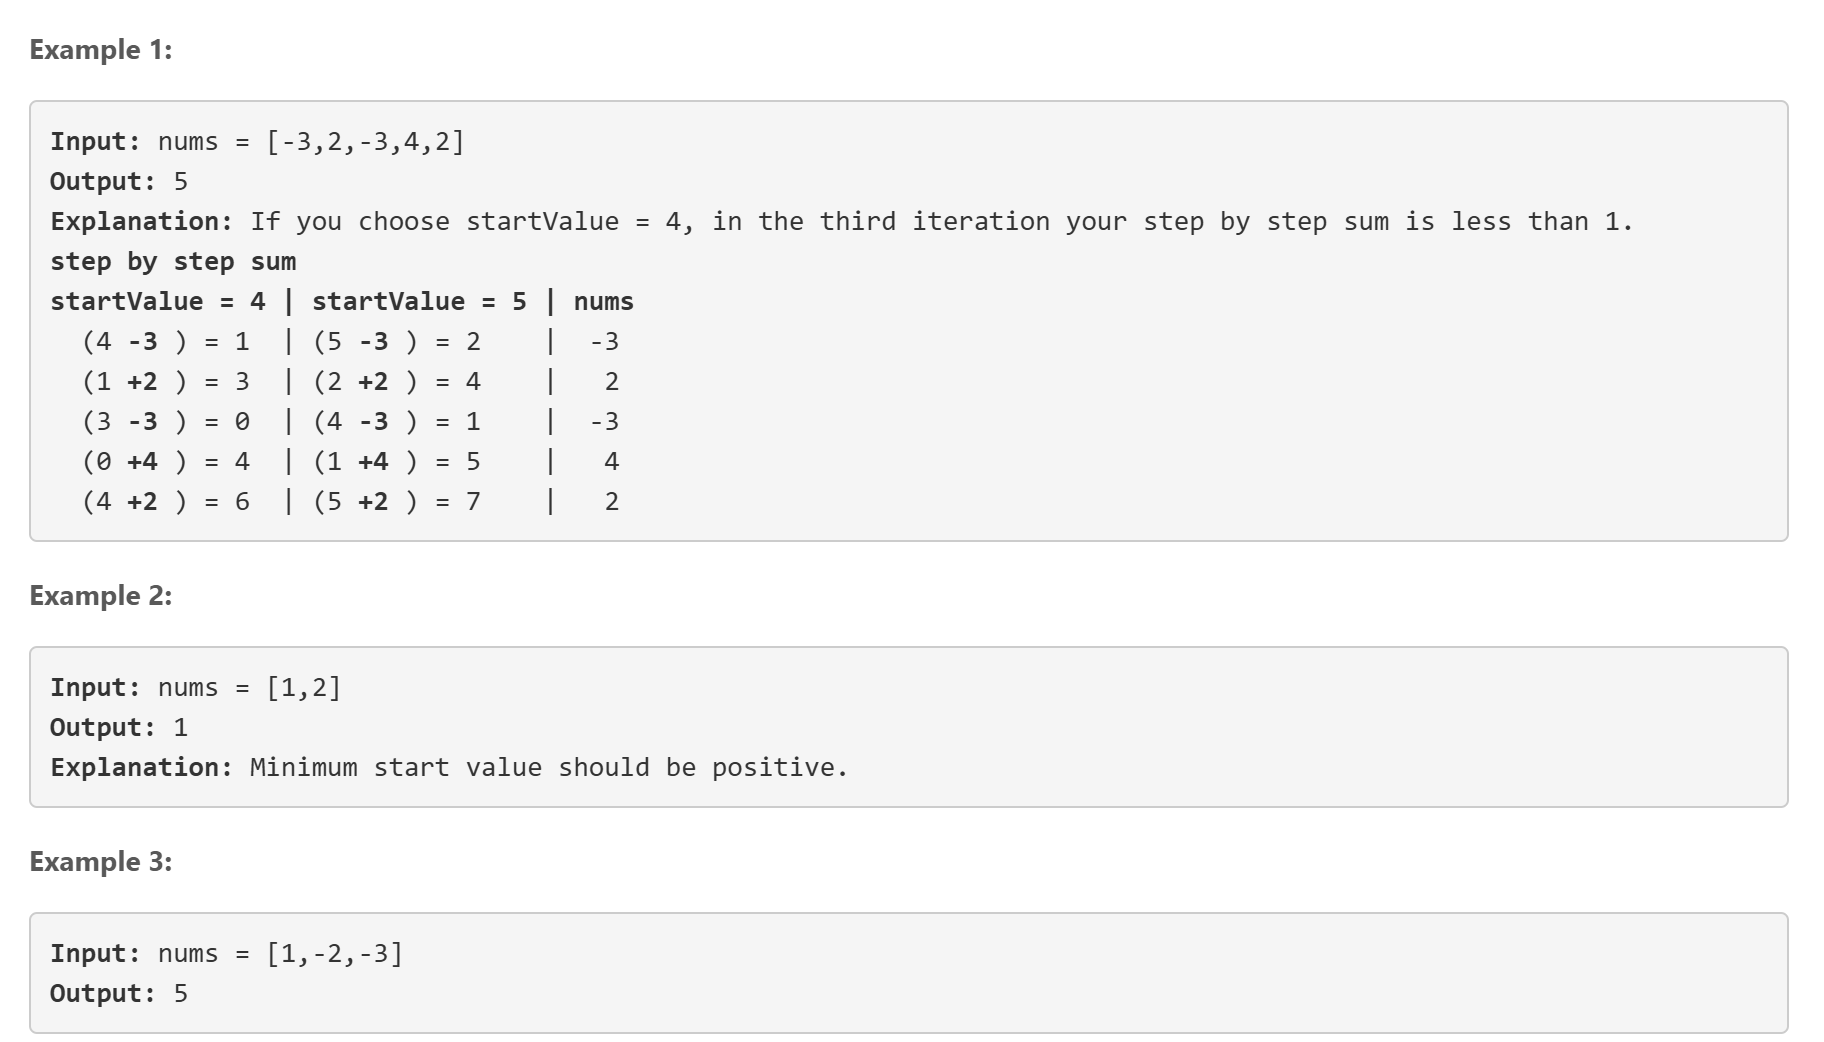


In [ ]:
def minStartValue(nums):
    start_value = 1

    while True:
        total = start_value
        is_valid = True

        for num in nums:
            total += num

            if total < 1:
                is_valid = False 
                break

        if is_valid:
            return start_value
        else:
            start_value += 1

In [ ]:
arr = [-3,2,-3,4,2]
minStartValue(arr)

# Exercise K Radius Subarray averages
You are given a 0-indexed array nums of n integers , and an integer k. The k raidus average for a subarray of nums centered at some index i with the radius k is teh average of all elements in nums between the indices i - k and i + k. If there are less than k elements before or after the index i, then the k-radius average is -1.

Build and return an array avgs of length n where avgs[i] is the k-radius average for the subarray centered at index i

In [ ]:
def getAverages(nums, k):
    if k == 0:
        return nums

    window_size = 2 * k + 1
    n = len(nums)
    averages = [-1] *  n


    if window_size > n:
        return averages

    prefix = [0] * (n+1)
    for i in range(n):
        prefix[i+1] = prefix[i] + nums[i]


    for i in range(k, n -k):
        leftBound, rightBound = i-k, i+k
        subArraySum = prefix[rightBound + 1] - prefix[leftBound] 
        average = subArraySum // window_size
        averages[i] = average

    return averages

##### O(n) string building 
We mentioned earlier that in most languages, strings are immutable this means concatenating a single character to a string is an o(n) oeperawiton 

Many problems will ask you to return a string, and usually this string will be builty during the algorithm. Let's say the final string is of lengthh n and we build it one character at a time with concatenation. Simple concatenation will result in a o(n^2) time complexity iterating over each individual array to concatenate adn doing this n times. 

There are better ways 

declare a list 
add character to teh list o(1) as lists are mutable
once finished conver the list to a sting using "".join(list) which is o(n)


subarray contiguous array
substring contiguoius string
subsequence same relative order but not contiguous
subset order sdoesn't matter


# Hashing

Primer on data structures

In the most basic terms, a data structure is a format for organizing data in an efficient way. In practical terms, we can split data structures into two things: the interface and the implementation.

The **interface** is like a contract that specifies how we can interact with the data structure what operations we can perform on it, what inputs it expects and what outputs we can expect. Basically, it's how we use the data strucutre. 

For example consider a dynamic array. The interface would include operations like appending insertion removal updating and more. These operations are well-defined and have specific rules that we must that we must follow when we use them. If we want to append an element we use built in methods like .append() and .push() while passing in the element we want to add as an argument.

The **implementation** is the code that actually makes the data structure work. This is where the details of how the data is stored and how the operations are performed come into play. For example, the implementation of the the dynamic array might involve allocating memory for the list, tracking the size, and rearranging the elements when an operation like remove is called.  

we only need to understand interface


A **hash** function is a function that takes an input and deterministically converts it to an integer that is less than a fixed size set by the programmer. Inputs are called keys and and the same input will always be converted to the same integer. 


What is the point of a hash function?

We know that arrays have O(1) random access. Given an arbitrary index, we can access and update its value in the array in constant time. The main constraint with arrays is that they are fixed size, and the indices have to be integers. 

Because hash functions can convert any input into an integer, we can effectively remove the constraint of indices needing to be integers. When a hash fucntion is combined with an array, it creates a hash map, also known as a hash table or dictionary.

with arrays we map indices to values

with hash maps, we map keys to values, and a key can be almost anything the only constraint is that it has to be immutable.

A hash map is probably the most important concept of all alforithms, it allows you to reduce the time complexity of an algorithm by a factor of O(n) for a huge amount of problems. Every major language has a built in implementation of a hash map. In python they are called dictionaries adn we declare one by **dic = {}**. 

To summarize a hash map is an unordered data structure that stores key-value pairs. A hash map can add and remove elements in O(1), as well as update values associated with a key and check if a key exists, also in O(1). You can iterate over both the keys and values of a hash map, but the iteration won't necessarily follow any order.

- An ordered data structure is one where the insertion order is 'remembered' .

- An unordered data structure is one where the insertion order is not relevant.

# Comparison with arrays

In terms of time complexity, hash maps blow arrays out of the water. the following operations are all O(1) for a hash map:
- add an element and associate it with a value
- delete an element if it exists
- check if an element exists

A hash map also has many of the same useful properties as an array with the same time complexity:
- find length / number of elements
- updating values
- iterate over elements#

Hash maps are also just easier/cleaner to work with. Even if your keys are integers and you could get away with using an array, if you don't know what the max size of your key is, then you don't know how large you should size your array. With hash maps, you don't need to worry about that, since the key will be converted to a new integer within the size limit anyways.

Disadvantages of hash maps: for smaller input sizes it cna be slower due to overhead, O(1) notation ignores constants it is usually more like O(10) as every key need to go through the hash function. Hash tables can also take up more space. Dynamic arrays are actually fixed size arrays that resize themselves when they go beyound their capacity. HT's are also implemented using a fixed size array rememebr ethe size is a limit set by the programmer. The probelm is resizing a ht is more expensive because every key needs to be re-hashed, and also a hash table may use an array that is significantly larger than the number of elements stored wasting space.


Note: remember that time complexity fucntions only involve the variables you define 



#### Sets

A set is another data structure that is very similar to a hash table. It uses the same mechanism for hashing keys into integers. The difference between a set and hash table is that sets do not map their keys to anything. Sets are more convenient to use when you only care about checking if elements exist. Sets dont track frequency.

###### Arrays as keys? 

We said tha being immutable is usually a requirement for being a hash map key. Arrays are mutable so how do we store an ordered collection of elements as a key? Depending on the language you're using, there are several ways ot convert an array into a unique immutable key. In python, tuples are immutable. tuple(arr).



In [ ]:
# Declaration: a hash map is declared like any other variable. The syntax is {}
hash_map = {}

# If you want to initialize it with some key value pairs, use the following syntax:
hash_map = {1: 2, 5: 3, 7: 2}

# Checking if a key exists: simply use the `in` keyword
1 in hash_map # True
9 in hash_map # False

# Accessing a value given a key: use square brackets, similar to an array.
hash_map[5] # 3

# Adding or updating a key: use square brackets, similar to an array.
# If the key already exists, the value will be updated
hash_map[5] = 6

# If the key doesn't exist yet, the key value pair will be inserted
hash_map[9] = 15

# Deleting a key: use the del keyword. Key must exist or you will get an error.
del hash_map[9]

# Get size
len(hash_map) # 3

# Get keys: use .keys(). You can iterate over this using a for loop.
keys = hash_map.keys()
for key in keys:
    print(key)

# Get values: use .values(). You can iterate over this using a for loop.
values = hash_map.values()
for val in values:
    print(val)

##### Checking for existence

One of the most common applications of a hash map or set is determining if an element exists in O(1). Since an array needs O(n) to do this , using a hash map or set can improtve teh time complexity of an alggorithm greatly, usually from O(n^2) to O(n).

##### Example Given an array of integers nums and an integer target, return indices of two numbers such that they add up to target. You cannot use the same index twice.

In [ ]:
def twosum(nums, target):
    dic = {} 
    for i in range(len(nums)):
        num = nums[i]
        complement = target - num
        if complement in dic:
            return [i, dic[complement]]

        dic[num] = i # hash map maps elements to there indices 

    return [-1, -1]

If the question wanted us to return a boolean indicating if a pair exists or to return the numbers themselves, then we could just use a set. However, since it wants the indices of the numbers, we need to use a hash map to "remember" what indices the numbers are at.
The time complexity is o(n) as the hash map operations are o(1) htis solution also uses O9n) space as teh number of keys the hash map will store scales linearly with the input size.

EXAMPLE given a string return the first letter to appear twice

In [ ]:
# brute force
def repeatedCharacter(self, s: str) -> str:
    for i in range(len(s)):
        c = s[i]
        for j in range(i):
            if s[j] == c:
                return c

    return ""

# This is O(n^2) due to the nested loop

# The second loop sic checking for the existence of c, which can be done using O(1) using a set

def repeatedCharacter(s):
    seen = set()
    for c in s:
        if c in seen:
            return c
        seen.add(c)

    return ""

# This improves our time complexity to O(n) as each for loop iteration now runs in constant time.

Example 3: Given an integer array nums, find all the numbers x in nums that satisfy the following x + 1 is not in nums and x - 1 is not in nums.
If a valid number x appears multiple times, you only need ot include it in the answer once
~

In [ ]:
def find_numbers(nums):
    ans = []
    nums_set = set(nums)

    for num in nums_set:
        if (num + 1 not in nums_set) and (num - 1 not in nums_set):
            ans.append(num)
    return ans

### Exercise Check if the sentence is a pangram where every letter of the english alphabet

Given a string sentence containing only lower case english letters, return true if sentence is a pangram or false otherwise.

In [ ]:
def ispangram(sentence):
   return len(set(sentence)) == 26

# Example Missing number
Given an array nums containing n distinct numbers in the range [0,n] return the only number in the rang ethat is missing from the array.


In [ ]:
def missingNumber(self, nums):
    num_set = set(nums)
    n = len(nums_ + 1)
    for number in range(n):
            if number not in num_set:
                return number
    

# Counting

Counting is a very common pattern with hash maps. By "counting" we are referring to tracking the frequency of things. This means our hash map will be mapping keys to integers. Anytime you need to count anything, think about using a hash map to do it. Recall that when we were looking at sliding windows, some problems had their constraint as limiting the amount of a certain element in the window. In those problems we could simply use an integer variable curr because we were only focused on one element. 

A hash map opens the door to solving problems where the constraint involves multiple elements. Let's start by looking at a sliding window example that leverages a hash map.

##### Example You are given a string s and an integer k. Find the length of the longest substring that contains at most k distinct characters.

This problem deals with substrings and has a constraint on the substrings (at most k distinct characters). These characteristics let us know that we should consider sliding window. Remember the idea of a sliding window is to add elements by sliding to the right until the window violates the constraint. Once it does , we shrink the window from the left until it no longer violates the constraint. In this problem we are concerned witht the number of distinct characters in the window the brute force way would be to check the entire window every time

Let's use a hash map counts to keep count of the characters in the window. This means we will map letters to their frequency. The length in counts at any time is the number of distinct characters. When we remove from the left, we can decrement the frequency of the elements being removed. When the frequency becomes 0, we know this charcater is no longer part of the window and we can delete the key.

In python the **collections module** provides very useful data structures. We will be using a defacultdict in the Python code. Functionality-wise, a default dict is the same as a hash map, it's just more pleasant to work with.



In [ ]:
from collections import defaultdict
def find_longest_substring(s,k):
    counts = defaultdict(int) # hashmap
    left = ans = 0  # sliding window variables
    for right in range(len(s)): # iterate over input
        counts[s[right]] += 1  # at each character add to window
        while len(counts) > k :  # while constraint is broken
            counts[s[left]] -= 1  # delete character at left pointer
            if counts[s[left]] == 0: # if after decrementing it then we have removed all character so we can delete from hashmap.
                del counts[s[left]]
            left += 1

        ans = max(ans, right - left + 1)
        
    return ans

Exercise 

Given a 2D array nums that contains n arrays of distinct integers return a sorted array containing all the numbers that appear in all n arrays. 

In [ ]:
def intersection(nums):
    counts = defaultdict(int)
    for arr in nums:
        for x in arr:
            count[x] += 1

    n = len(nums)
    ans = []
    for key in counts:
        if counts[key] == n:
            ans.append(key)

    return sorted(ans)

#### Example Check if all characters have equal number of occurrences 
Given a string s determine if all characters have the same frequency.

In [ ]:
def areOccurencesEqual(s):
    counts = defaultdict(int)
    for c in s:
        counts[c] += 1

    frequencies = counts.values()
    return len(set(frequencies)) == 1

# Count the number of subarrays with an exact constraint old mission

In the sliding window article , we talked about a pattern "find the number of subarrays/ susbtrings that fit a constraint" In those problems, if you had a window between left and right that fit the constraint, then all windows from i to right also fit the constraint where left < i <= right

For this pattern we will be looking at problems with stricter constraints so that the property just mentioned is not necessarily true.

For example " Find the number of subarrays that have a sum less than k" with an input that only has positive numbers woudl be solved with sliding window . In this section we would be talking about questions like **find the number of subarrays that have a sum exactly equal to k**


We must recall the concept of prefix sums.

The sum of any subarray can be found as the difference between two prefix sums. Let's say that you wanted to find subarrays that had a sum exactly equal to k, and you also had a prefix sum array of the input. You know that any difference in the prefix sum array equal to k represents a subarray with a sum equal to k. So how do we find these differences? 

Lets first declare a hash map counts that maps prefix sums to how often they occur 

then we iterate over the input and maintain the sum of the current prefix in a variable curr. At any given time, curr represents the sum of all the elements we have iterated over so far. We'll also maintain counts by incrementing the frequency of curr at each iteration. Remember counts is counting how many times a sum has appeared in a prefix.

How do we calculate the answer , recall that in the sliding window article, when we were looking for the number of subarrays we focused on each index and figured out how many valid subarrays ended at the current index. Essentially we locked in the right bound and calculated how many left bounds coudl match it. We will do the same thing here. Let's say that we're at an index i. We know:
1) Up until this point curr stores the prefix of all elements up to i
2) we have stored all other prefixes before i inside of counts
3) The difference between any two prefix sums represents a subarray. For example, if you wanted the subarray starting at index 2 and startin at index 8 , you would take the prefix up to 8 and subtract the prefix from 3 from it.
Now imagine there exists a subarrya that beginning at index j and ending at index i with a sum of k.

Consider the sum of the prefix ending at j - 1 (the elements up to, but not including the start of the subarry)

The sum of the prefix up to i is curr
The sum of the subarray from j to i is k 

Thus the sum of the prefix endidng at j-1 must be curr - k

This is the key idea: if we saw the prefix sum curr - k before, it necessarily implies that there is a subarray ending at i with a sum of k. We don't know where the beginning of this subarray is we jist know it exists but that's enough t to solve the problem.

Therefore, we can increment our answer by counts [curr - k] If the prefix curr - k occurred multiple times before then each of those prefixes could be used as a starting point to form a subarray ending at the current index with a sum of k. That's why we need to trakc the frequency.

Let's use a concrete example to better illustrate this idea. Imagine we had nums = [0, 1, 2, 3, 4] and k = 5. Let's jump to i = 3.

Currently, curr = 6 (remember, curr is tracking the prefix sum up to i). We also have 0, 1, and 3 in counts (all the prefix sums we have encountered so far).

At this point, we can see that there is a subarray ending at i with a sum of k - it's [2, 3]. How does our algorithm see it though?

The current prefix sum is 6. We want a subarray with a sum of 5. Thus, if there was a prefix sum of 1 earlier, you could just subtract that prefix from the current one, and you'll get a subarray sum of 5. In this case, we had a prefix [0, 1] which has a prefix sum of 1. We can subtract that from the current prefix [0, 1, 2, 3] and we're left with [2, 3], which has our target sum.

Remember in two sum we wanted target. We locked in a number num and searched for target - num. Here we lock in curr and search for curr - k, because curr - (curr - k) = k.  In two sum we dealt with numbers in the array directly. Here we deal with prefix sums of the array. 

# Example 4 given an integer array nums and an integer k find the number of subarrays whose sum is equal to k

In [ ]:
def subarraySum(nums, k):
    counts = defaultdict(int) # declare our hashmap that maps prefix sums to their frequency
    counts[0] = 1  # empty subarray has a prefix sum of zero 
    ans = curr = 0 # answer and current prefix sum initialised

    for num in nums: # iterate over input
        curr += num # at each number we add it to prefix sum
        ans += counts[curr - k]  # check if the prefix sum - k has appeared already and if it has we add to our answer
        counts[curr] += 1 # increase the current prefix sums count by 1

    return ans


# Count the Number of nice subarrays

Given an array of positive integers nums and an integer k. Find the number of subarrays with exactly k odd numbers in them.

For example, given nums = [1,1,2,1,1] k = 3 the answer is two. The subarrays with 3 odd numbers in them are [1, 1, 2, 1, 1] and [1, 1, 2, 1, 1]

In [ ]:
def numberOfSubarrays(nums, k):
    counts = defaultdict(int)
    counts[0] = 1 
    ans = curr = 0 

    for num in nums:
        curr += num % 2
        ans += counts[curr - k]
        counts[curr] += 1

    return ans

### Find Players with Zero or One losses
You are given an integer array matches where matches[i] = [winner_i , loser_i] indicates that the player winner i defeated player loser in a match

Return a list answer of size 2 where 
answer[0] is a list of all players that have not lost any matches
answer[1] is a list of all players that have lost exactly one match

the values in the two lists should be returned in increasing order


In [ ]:
def findWinners(matches):
    losses_count = {}
    
    for winner, loser in matches:
        losses_count[winner] = losses_count.get(winner, 0)
        losses_count[loser] = losses_count.get(loser, 0) + 1
    
    zero_lose, one_lose = [], []
    for player, count in losses_count.items():
        if count == 0:
            zero_lose.append(player)
        if count == 1:
            one_lose.append(player)
    
    return [sorted(zero_lose), sorted(one_lose)]

### Maximum Number of Balloons 

Given a string text, you want to use the characters of text to form as many instances of the word "balloon" as possible. 
You can use each character in text at most once. Return the maximum number of instance that can be formed.

In [ ]:
def max_number_of_balloons(s):
    freq = {}

    for ch in text:
        freq[ch] = freq.get(ch, 0) + 1 # returns the current count of ch if it exists in the dictionary otherwise it returns to 0 and we add and then assign it back

    need = {'b' : 1, 'a': 1, 'l': 2, 'o':2, 'n': 1}

    ans = float('inf')
    for ch, req in need.items():
        ans = min(ans, freq.get(ch, 0) // req)

    return 0 if ans == float('inf') else ans

#### Contiguous Array

Given a binary array nums, return the maximum length of a contiguous subarray with an equal number of 0 and 1

In [ ]:
def findMaxLength(nums):
    dic = {}
    dic[0] = -1
    ans = 0
    count = 0

    for i in range(len(nums)):
        if nums[i] == 1:
            count += 1
        else:
            count -= 1
            
        if count in dic:
            ans = max(ans, i - dic[count])
        else:
            dic[count] = i
    
        return ans 

### Example Group Anagrams

Given an array of strings strs, group the anagrams together. For example, given strs = ["eat","tea","tan","ate","nat","bat"], return [["bat"],["nat","tan"],["ate","eat","tea"]].

how can we check if two strings are anagrams of each other? We could use two hash maps, count all the characters in each string and tehn compare if the hash maps are the same. This is very cumbersome to implement and also doesn't help us with grouping strings together if a group has more than 2 strings. For each group, we need a way to uniquely identify the group.

The cleanest way to know if two strings are anagrams of each other is by checking if they are equal after both being sorted. Also all strings in a group will be the same when sorted, so we can use the sorted version as a key.

We can map these keys to the groups themselves in a hash map, and then our answer is just the values of the hash map. 

Essentially , every group has its own 'identifier' (the sorted string) and we can use this identifier to group them in a hash map easily.

In [ ]:
from collections import defaultdict

def groupAnagrams(strs):
    groups = defaultdict(list)
    for s in strs:
        key = "".join(sorted(s))
        groups[key].append(s)

    return list(groups.values())

Note for Python: dictionary.values() doesn't actually return a list but actually a view object. We need to convert it to a list first.

Given n as the length of strs and m as the average length of the strings, we iterate over each string and sort it.

#### Example 2 Minimum Consecutive cards to pick up
Given an integer array cards, find the length of the shortest subarray that contains at least one duplicate. If the array has no duplicates, return -1.

We can actually solve this problem using a sliding window, but we use a hash map. This question is equivalent ot what is the shortest distance between any two of the same element?

In [ ]:
from collections import defaultdict

def minimumCardPickup(self, cards):
    # create a dictionary that maps each card value to a list of indices 
    dic = defaultdict(list)

    # iterate over all indices of the input list ' cards'
    for i in range(len(cards)):
        # append the current index i to the list corresponding to the value cards[i]
        # After this loop, dic[x] contains all positiions where card x appears
        dic[cards[i]].append(i)

    # Initialize the answer with +infinity
    # we are going to minimize over subarray lengths
    ans = float("inf")

    # Iterate over each distinct card value stored in the dictionary
    for key in dic:
        # retrieve the list of indices where this card value occurs
        arr = dic[key]

        # if a card occurs k times, there are (k-1) adjacent pairs
        # we check distances between consecutive occurrences
        for i in range(len(arr) - 1):
            # arr[i+1] - arr[i] gives the distance between two equal cards
            ans = min(ans, arr[i + 1] - arr[i] + 1)
    
    return ans if ans < float("inf") else -1

## Example Max sum of a pari with equal sum of digits.
Given an array of integers nums, find the maximum value of nums[i] + nums[j] where have the same digit sum. Return -1 if there is no pair of numbers with the same digit sum.

In [ ]:
    def maximumSum(self, nums) -> int:
        def get_digit_sum(num):
            digit_sum = 0
            while num:
                digit_sum += num % 10
                num //= 10
            
            return digit_sum
        
        dic = defaultdict(int)
        ans = -1
        for num in nums:
            digit_sum = get_digit_sum(num)
            if digit_sum in dic:
                ans = max(ans, num + dic[digit_sum])
            dic[digit_sum] = max(dic[digit_sum], num)

        return ans

### Equal Row and Column Pairs
Given an nxn matrix grid, return the number of pairs (R,C) where R is a row and C is a column and R and c are equal if we consider them as 1D arrays.

How can we calculate the number of equal pairs? Let's say there are three rows that look like [1, 2, 3], and there are two columns that also look like [1, 2, 3]. For each of the three rows, there are two columns to pair with, so that means there are 3 * 2 = 6 pairs. We can use a hash map to count how many times each row occurs. We can use a second hash map to do the same thing with the columns. Then, we can iterate over the rows hash map, and for each row, check if the same array appeared as a column. If it did, then the product of the number of appearances is added to our answer.
The problem is, arrays can't be put in a hash map as a key because they are mutable. We need to convert the rows and columns into a hashable form such as a string or tuple. The best choice will depend on the language you're using.


In [ ]:
from collections import defaultdict
from typing import List

class Solution:
    def equalPairs(self, grid: List[List[int]]) -> int:
        """
        Given an n x n matrix 'grid', this function counts the number of pairs (i, j)
        such that the i-th row is exactly equal to the j-th column.
        """

        def convert_to_key(arr):
            """
            Lists are mutable and therefore not hashable in Python, which means
            they cannot be used as dictionary keys. Tuples, however, are immutable
            and hashable.

            This function performs the canonical embedding:
                R^n (represented as a list) -> hashable key (tuple)

            allowing vectors (rows or columns) to be counted using a dictionary.
            """
            return tuple(arr)

        # dic will store the frequency of each distinct row vector
        # Formally: dic[x] = number of rows equal to vector x
        dic = defaultdict(int)

        # Iterate over all rows in the matrix
        for row in grid:
            # Convert the row into a hashable representation
            # and increment its frequency
            dic[convert_to_key(row)] += 1

        # dic2 will store the frequency of each distinct column vector
        # Formally: dic2[y] = number of columns equal to vector y
        dic2 = defaultdict(int)

        # Iterate over column indices
        for col in range(len(grid[0])):
            current_col = []

            # Construct the column vector explicitly by fixing the column index
            # and varying the row index
            for row in range(len(grid)):
                current_col.append(grid[row][col])

            # Convert the column into a hashable representation
            # and increment its frequency
            dic2[convert_to_key(current_col)] += 1

        # The final answer accumulates the number of matching row–column pairs
        ans = 0

        # For each distinct vector appearing as a row,
        # multiply its row frequency by its column frequency
        #
        # Mathematically:
        # If a vector v appears r times as a row and c times as a column,
        # it contributes r * c valid (row, column) pairs.
        for arr in dic:
            ans += dic[arr] * dic2[arr]

        # Return the total count of equal row–column pairs
        return ans


### Given two strings ransomNote and magazine, return true if ransomNote can be constructed by using the letters from a magazine false otherwise

one approach would be to go through each letter in ransomNote and look for the letter in magazine to see if present, then move on. If the letter can't be found in magazine we return false

However strings are immutable so when we want to remove a letter from magazine we must create a new string copy over the new letters and overwrite magazine with a new string O(nxm) for each letter in ransom note n we : 1) look through magazine o(m) 2) copy (m-1) letter o(m). so in total we have O(nx(m+m)) = O(n x m)

The hash map approach is better, hash map is a data structure with constant time access for any of its elements specified by a key.

When approaching a probelm where one needs to track frequency a hash map is perfect.

All we need in this problem is frequency not order so hm is suitable.

In [ ]:
def canConstruct(ransomNote, magazine):

    if len(ransomNote) > len(magazine):
        return False

    magazine_counts = collections.Counter(magazine) # frequency hash map created
    ransom_notes_counts = collections.Counter(ransomNote)

    # for each unique character in the ransom note
    for char, count in ransom_notes_counts.items():
        # check that the count of char in the magazine is equal or higher than in ransom note
        magazine_count = magazine_count[char]
        if magazine_count < count:
            return False
    return True

In [ ]:
import collections
sing = "aAAbbbb"
hm = collections.Counter(sing)
hm

In [27]:
from collections import defaultdict
hm = defaultdict(int)
hm
for ch in sing:
    hm[ch] += 1
hm

defaultdict(int, {'a': 1, 'A': 2, 'b': 4})

In [26]:
from collections import defaultdict
hm = {}
for ch in sing:
    if ch in hm:
        hm[ch] += 1
    else:
        hm[ch] = 1
hm

{'a': 1, 'A': 2, 'b': 4}

In [28]:
hm = collections.Counter(sing)
hm

Counter({'b': 4, 'A': 2, 'a': 1})

# You're given strings jewels representing the types of stones that are jewels, and stones representing the stones you have. Each character in stones is a sype of stone you have. You want to know how many of the stones you have are also jewels. 
Letters are case sensitive a != same stone as A.

In [ ]:
def numJewelsInStones(jewels: str, stones: str) -> int:

    jewel_hm = {j:0 for j in jewels} # constructs dictionary whose keys are the character in jewels assigning each 0
    #jewel_hm == {"a": 0, "A": 0}

    for s in stones:
        if s in jewel_hm:  # is stone in jewel set
            jewel_hm[s] += 1 # counts jewels in your stones
            
    return sum(jewel_hm.values())    #.values returns view dict_values([2, 1, 0]) it is an iterable not a list, sum can be done over any iterable
    

In [33]:
def hashsetsol(J,s):
    Jset = set(J)
    return sum(s in Jset for s in S)
stones = "aAbbbb"
jewels = 'Ab'
from collections import Counter
stone_counts = Counter(stones)
sum(stone_counts[j] for j in jewels)

5

#### Longest Substring without Repeating Characters

Given a string S, find the length of the longest substring without duplicate characters

# sliding window plus hash map to store index where character appeared

In [35]:
def LengthOfLongestSubstring(s):
    last = {} # dictionary stores most recent INDEX wher the character appeared
    left = 0
    best = 0
    for right, ch in enumerate(s): # enumerate makes each element a tuple with its index (index, element) here we iterate through each tuple
        
        # if ch is inside the current window then we must remove the duplicate by shifting left boundary
        
        if ch in last and last[ch] >= left: # if character has been seen before and index position of ch is in our current window
            
            left = last[ch] + 1  # remove duplicate by updating left boundary index of window

        last[ch] = right # assign the most recent index of the character ch ot the dictionary in last

        best = max(best, right - left + 1) # updates maximum length of a valid substring encountered so far

    return best

iteration 1 right = 0 ch = 'a' , a is  not in last so we assign last['a'] = 0, then update best = max(0, 0 - 0 + 1) = 1
iteration 2 right = 1 ch = 'b' ,......, last['b'] = 1 then update best = max(1, 1 - 0 + 1) = 2
iteration 3 right = 2, ch = 'b' , b is in last and b >= left = 0, so left = last['b'] + 1  = 2 last ['b'] = 2, best(max(2,2-2+1) = 1

Consider the string s = "abba". Initially, the dictionary last is empty, the left pointer is 0, and the best length is 0. At index right = 0 the character is 'a', which has not been seen before, so we record last['a'] = 0 and the current window length is 1, updating best to 1. At right = 1 the character 'b' is new, so we set last['b'] = 1; the window "ab" has length 2 and best becomes 2. At right = 2 the character 'b' appears again, and since its previous index 1 lies within the current window, the left boundary is moved to index 2 and last['b'] is updated to 2; the current window is now "b" with length 1, so best remains 2. Finally, at right = 3 the character 'a' appears again, but its previous index 0 lies outside the current window, so the left boundary does not change; we update last['a'] = 3, the window "ba" has length 2, and the algorithm finishes with best equal to 2, which is the length of the longest substring without repeating characters.

# Linked Lists

#### Nodes

A **node** can be though of as an element, but with more information than just one piece of data like an integer or string. Nodes are an abstract idea - for example let's say you had an array [1,2,3]. You could imagine each element as a node with two pieces of information, the integer and the index

So the second element would be data: 2 index : 1

Arrays are implemented under the hood in a way that the elements are stored contiguously in memory. Let's say you declared an arry to hold 32 bit integers. Each element in the array is at an address that is 4 bytes (32 bits) away from its neighbors). This allows the programmer to access elements in an array with indexing like arr[6]

A linked list is a data structure that is similar to an array. It also stores data in an ordered manner, but it is implemented using node objects (you will have a custom class that defines the node object). Each node will have a 'next' pointer, which points to the node representing the next element in the sequence.

Next is some example code for creating a linked list ot represent the data 1 -> 2 -> 3. As you can see the class that defines a node has a field val which will hold the data and a next pointer which references the next node. In the code,we are creating three nodes, one for each number then setting the next pointers accordingly~

In [40]:
class ListNode:
    def __init__(self, val):
        self.val = val
        self.next = None


one = ListNode(1)
two = ListNode(2)
three = ListNode(3)

one.next = two 
two.next = three 
head = one

print(head.val)
print(head.next.val)
print(head.next.next.val)

1
2
3


We call the node with the 1 the **head** beacuse it is the start of the linked list. Usually you will want to keep the reference at the head. This is because the head is the only node from where you can reach all elements in the linked list, so by keeping a reference to it, you ensure that you never lose any elements.

Main advantage of a linked list is that you can add and remove elements in O(1). The caveat is that you need to have a reference to a node at the position in which you want to perform the addition/removal otherwise the operation is O(n), becasue you will need to iterate starting from the head until you get to the desired position. This is still much better than a normal(dynamic) array, which requieres O(n) for adding and removing an arbitrary position.

The main disadvantage of a linked list is that there is no random access. If you have a large linked list and want to acces sthe 15000th element there isn't a better way than iterating through the whole list where as an array has O(1) indexing.

Linked lists dont have fixed sizes unlike arrays which are fixed sizes under the hood even for dynamic arrays.

#### Mechanics of a linked list

##### Assignment (=)
When you assign a pointer to an existing linked list nodem the pointer refers to the object in memory. Let's say you have a node head:

In [37]:
ptr = head
head = head.next
head = None

After these lines of code ptr still refers to the origianl head node, even though the head variable changed. This is the first important concept: variables remain at nodes unless they are modified directly. ptr = something is the only way to modify ptr#

##### Chaining.next

If you have multiple .next for example: head.next.next everything before the final .next refers to one node. For example, given a linked list 1 -> 2 -> 3, if you have head pointing at the first node, and you do head.next.next, you are actually referring to 2.next, because head.next is the 2. We'll soon see that this is a very useful technique.

#### Traversal
Iterating forward through a linked list can be done with a simple loop. This is the usual code that you will use to do so : for example gettign the sum of all values from an integer linked list

In [41]:
def get_sum(head):
    ans = 0 
    while head:
        ans += head.val
        head = head.next
    return ans

get_sum(one)

6

 KEY : the final node's next pointer is null. therefore after doing head = head.next at the final node teh head becomes null and the while loop ends.

 Moving to head.next is the equivalent of iterating to the next element in an array. traversal can also be done recursively.

In [43]:
def get_sum(head):
    if not(head):
        return 0

    return head.val + get_sum(head.next)

### Types of linked lists

####  Singly linked list

This is the most common type of linked list and the one that is given in the code above. In a singly liked list, each node only has a pointer to the next node. This means you can only move forward in the list when iterating. The pointer used to reference the next node is usally called next

Let's say you want to delete the element at position i. Again you need to have a pointer to the element currently at poisition i - 1. The element at position i+1 call it x, will be shifted over to be at position i, after the deletion. Therefore, you shoudl set x as the next node to the element currently at position i - 1. 

In [44]:
class ListNode:
    def __init__(self, val):
        self.val = val
        self.next = None

# Let prev_node be the node at position i - 1
def delete_node(prev_node):
    prev_node.next = prev_node.next.next

prevNode.next is the node being deleted. prevNode.next.next is the node after that which should be kept. We change the next pointer of prevNode to point at that node instead of the one being deleted.

Because the node being deleted could only have been reached from prevNode and we have now severed that connection, it is no longer part of the list.

As mentioned before, when you have a reference to the node at i - 1, then insertion and deletion is 
O
(
1
)
O(1). However, without that reference, you need to obtain the reference by iterating from the head, which for an arbitrary position is 
O
(
n
)
O(n).

#### Doubly linked list

A doubly linked list is like a singly linked list but each node also contains a pointer to the previous node. 

In a singly linked list, we needed a reference to the node at i - 1 if we wanted to add or remove at i. This is because we needed to perform operations on the prevNode. With a doubly linked list, we only need a reference to the node at i. This is because we can simply reference the prev pointer of that node to get the node at i - 1, and then do the exact same operations as above.

With a doubly linked list, we need to do extra work to also update the prev pointers.

In [45]:
class ListNode:
    def __init__(self, val):
        self.val = val
        self.next = None
        self.prev = None

# Let node be the node at position i
def add_node(node, node_to_add):
    prev_node = node.prev
    node_to_add.next = node
    node_to_add.prev = prev_node
    prev_node.next = node_to_add
    node.prev = node_to_add

# Let node be the node at position i
def delete_node(node):
    prev_node = node.prev
    next_node = node.next
    prev_node.next = next_node
    next_node.prev = prev_node

##### Linked lists with sentinal nodes

We call the start of a linked list the **head** and the end of a linked list the **tail**.

Sentinel nodes sit at the start and end of linked lists and are used to make operations and the code needed to execute those operations cleaner. The idea is that even when there are no nodes in a linked list, you still keep pointers to a head and tail. the real head of the linked list is head.next and the real tail of a linked list is tail.prev. the sentinel nodes themselves are not part of our linked list.

The sentinel nodes also allow us to easily add and remove from the front or back of the linked list. Recall that addition and removal is only 
O
(
1
)
O(1) if we have a reference to the node at the position we are performing the operation on. With the sentinel tail node, we can perform operations at the end of the list in 
O
(
1
)
O(1).

In [46]:
class ListNode:
    def __init__(self, val):
        self.val = val
        self.next = None
        self.prev = None

def add_to_end(node_to_add):
    node_to_add.next = tail
    node_to_add.prev = tail.prev
    tail.prev.next = node_to_add
    tail.prev = node_to_add

def remove_from_end():
    if head.next == tail:
        return

    node_to_remove = tail.prev
    node_to_remove.prev.next = tail
    tail.prev = node_to_remove.prev

def add_to_start(node_to_add):
    node_to_add.prev = head
    node_to_add.next = head.next
    head.next.prev = node_to_add
    head.next = node_to_add

def remove_from_start():
    if head.next == tail:
        return
    
    node_to_remove = head.next
    node_to_remove.next.prev = head
    head.next = node_to_remove.next

head = ListNode(None)
tail = ListNode(None)
head.next = tail
tail.prev = head

##### Dummy pointers
As mentioned earlier, we usually want to keep a reference to the head to ensure we can always access any element. Sometimes, it's better to traverse using a "dummy" pointer and to keep head at the head.

In [48]:
def get_sum(head):
    ans = 0
    dummy = head
    while dummy:
        ans += dummy.val
        dummy = dummy.next
    
    # same as before, but we still have a pointer at the head
    return ans

# Using the dummy pointer allows us to traverse the linked list without losing a reference to the head.

A large part of linked lists is moving pointers around. It's important to build an intuition behind how to crrectly reassign pointers and the order in which the reassignments should happen.
The point of these problems is usually to manipulate pointers in a clean way using 
O
(
1
)
O(1) space.

In many cases, you could simply iterate through the linked list and put all the elements in an array, then just solve the problem using the array. 

####  Fast and slow pointers

Fast and slow pointers is an implementation of the two pointers technique that we learned in teh arrays and strings chapter. The idea is to have two pointers that don't move side by side. This means that they can mvoe at different 'speeds' during iteration begin iteration from different locations or any other abstract difference.

When the pointers move at different speeds, usually the 'fast' pointer moves two nodes per iteration, whereas the "slow" pointer moves one node per iteration.

Example 1: Given the head of a linked list with an odd number of nodes head, return the value in the middle.##


In [49]:
def get_middle(head):
    slow = head
    fast = head
    while fast and fast.next:
        slow = slow.next
        fast = fast.next.next
    
    return slow.val

# the pointers use O(1) space and O(n) for the traversals

###### Example 2 Linked list cycles
Given the head of a linked list, determine if the linked list has a cycle.

There is a cycle in a linked list if there is some node in the list that can be reached again by continuously following the next pointer.

The better approach is to use a fast and slow pointer. Imagine a straight racetrack (like the one used in the 100m sprint). If two runners of significantly different speeds are racing, then the slower one will never catch up to the faster one. The faster runner finishing the race is like the fast pointer reaching the end of the linked list.

But what if the runners were instead running around a circular racetrack, and needed to complete many laps? In that case, the faster runner will eventually pass (lap) the slower runner.

We can apply this logic - move a fast pointer twice the speed of a slow pointer. If they ever meet (except at the start), then we know there must be a cycle. If the fast pointer reaches the end of the linked list, then there isn't a cycle.

In [51]:
class Solution:
    def hasCycle(self, head) -> bool:
        slow = head
        fast = head
        while fast and fast.next:
            slow = slow.next
            fast = fast.next.next
            if slow == fast:
                return True

        return False

###### Example 3 Given the head of a linked list and an integer , return the kth node from the end.

In [52]:
def find_node(head, k):
    slow = head
    fast = head

    # even though we can see that there is k nodes in a list when you are given the head node your algorithm can't actually figure out the length 
    # of the linked list so we use two pointers
    
    for _ in range(k):
        fast = fast.next  # fast pointer is k ahead of slow

    # eventually when the fast reaches a null value the slow pointer is k from the end   
    while fast: 
        slow = slow.next 
        fast = fast.next 
    
    return slow

###### Exercise Given the head of a sorted linked list, delete all duplicates such that each element appears only once. Return the linked list sorted as well.

In [53]:
class Solution:
    def deleteDuplicates(self, head: ListNode) -> ListNode:
        current = head
        while current is not None and current.next is not None:  # while
            if current.next.val == current.val: # if the next nodes value is the same as the current make node point to node after next
                current.next = current.next.next
            else:
                current = current.next # continue exploration from current which we have updated to 
        return head # we have not removed the head but changed the linked list structure. 

# Reversing a linked list

Imagine that we have a linked list 1 -> 2 -> 3 -> 4, and we want to return 4 -> 3 -> 2 -> 1. Let's say we keep a pointer curr that represents the current node we are at. Starting with curr at the 1, we need to get the 2 to point to curr. The problem is, once we iterate (curr = curr.next) to get to the 2, we no longer have a pointer to the 1 because it is a singly linked list. To get around this, we can use another pointer prev that tracks the previous node.

At any given node curr, we can set curr.next = prev to switch the direction of the arrow. Then, we can update prev to be curr in preparation for the next node. However, if we change curr.next, we will lose that next node. To fix this, we can use a temporary variable nextNode to point to the next node before changing any of the other pointers.

In [54]:
def reverse_list(head):
    prev = None
    curr = head
    while curr:
        next_node = curr.next # first, make sure we don't lose the next node
        curr.next = prev      # reverse the direction of the pointer
        prev = curr           # set the current node to prev for the next node
        curr = next_node      # move on
        
    return prev

This exercise is a great one to practice operations on a linked list because it demonstrates the thought process needed. Solutions to linked list problems are usually simple and elegant - to get to them, think about what you need, and solve the problem one step at a time. In this example, we had the following thought process:

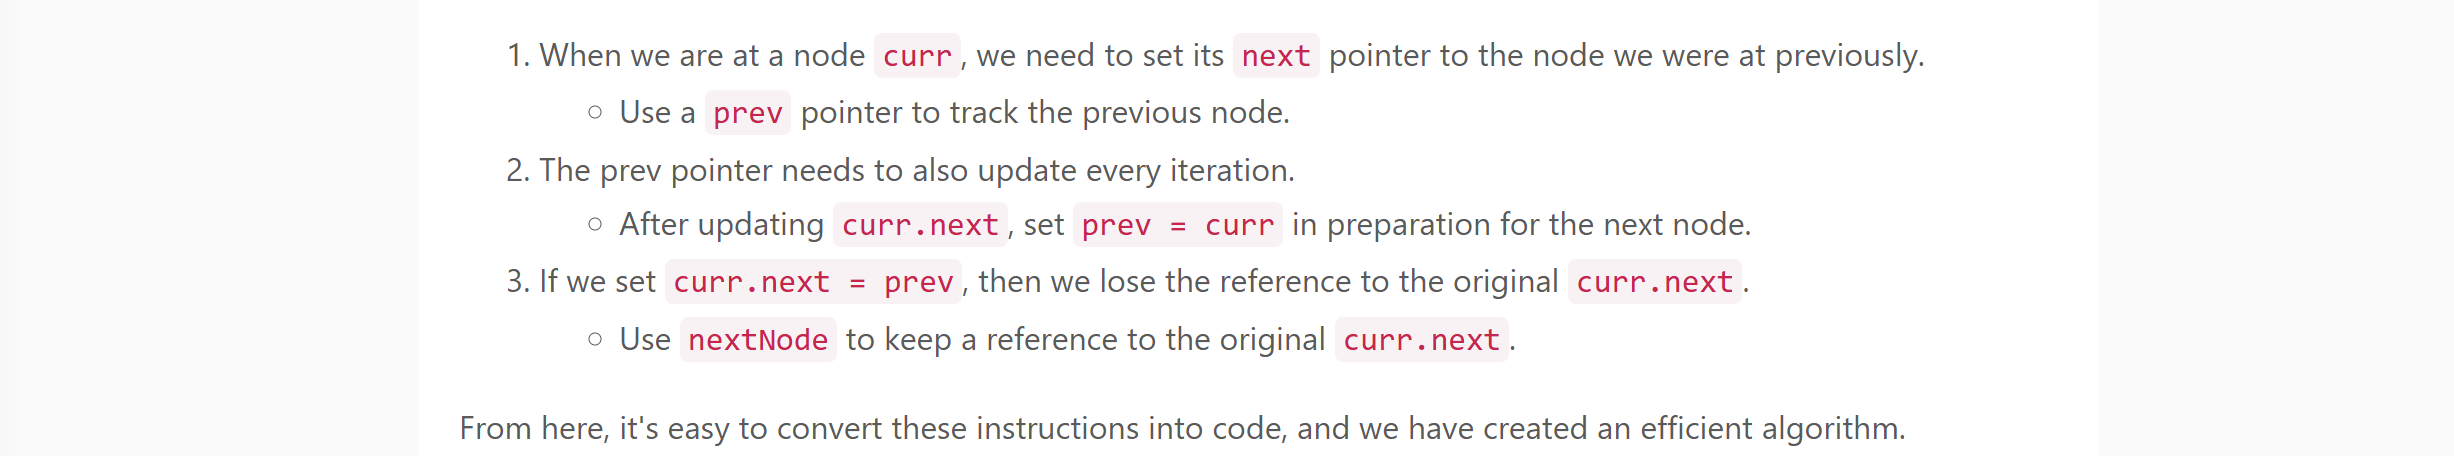

# Stacks
A stack is an **ordered collection of elements where elements are only added and removed from the same end.** In the physical world, an example of a stack would be a stack of plates in a kitchen you add or remove plates from the top of the pile. In the software world a good example of a stack is the hsitory of your current browswers tab. Let's say you'r on site A, and you click on a link to go to site B, then from B you click on another link to go to site C. every time you click a link, you are adding ot the stack. When you click the back arrow you remove from teh stack

Another term used to describe stacks is LIFO which stands for **last in, first out**. The last (most recent) element placed inside is the first element to come out.

Stacks are very simple to implement. In python you can jst use a list stack =[] and use **stack.append(element) and stack.pop()**.. In fact any dynamic array can implement a stack. 

Typically inserting into a stack is called **pushing** and removing from a stack is called **popping**. Stacks will usually also come with operations like **peek** which means lookign at the element at the top of the stack. #

The time complexity of stack operations is dependent on the implementation. If you use a dynamic array, which is the most comon and easiest way, then the time complexity of your operations is the same as that of a dynamic array. O(1) push pop and random access O(n) search. 

The characteristic that makes something a "stack" is that you can only add and remove elements from the same end. It doesn't matter how you implement it, a "stack" is just an abstract interface.

Stacks and recursion are very similar. This is because recursion is actually done using a stack. Function calls are pushed on a stack. The call at the top of the stack at any given moment is the "active" call. On a return statement or the end of the function being reached, the current call is popped off the stack.

For algorithm problems, a stack is a good option whenever you can recognize the LIFO pattern. Usually, there will be some component of the problem that involves elements in the input interacting with each other. Interacting could mean matching elements together, querying some property such as "how far is the next largest element", evaluating a mathematical equation given as a string, just comparing elements against each other, or any other abstract interaction. Sometimes, the LIFO property is hard to see, but we'll make sure to talk about how we recognize it in this chapter.

In [55]:
# Declaration: we will just use a list
stack = []

# Pushing elements:
stack.append(1)
stack.append(2)
stack.append(3)

# Popping elements:
stack.pop() # 3
stack.pop() # 2

# Check if empty
not stack # False

# Check element at top
stack[-1] # 1

# Get size
len(stack) # 1

1

#### String Problems

String questions involving staccks are popular. Normally, string questions that can utilize a stack will involve iterating over the string and putting characters into the stack, and comparing the top of the stack with the current character at each iteration. Stacks are useful for string matching because it saves a 'history' of the previous characters.

###### Example Valid Parenthesis
Given a string s containing just the characters '(', ')', '{', '}', '[' and ']' , determine if the input string is valid. The string is valid if all open brackets are closed by the same type of closing bracket in the correct order, and each closing bracket closes exactly one open bracket.


The correct order is determined by whatever the previous opening bracket was. whenever there is a closign bracket, it should correspond to the most recent opening bracket. For example, if the string starts "({[" and the next 3 characters are closing brackets, then they should be in the order of how recently their opening bracket appeared "]})".


The order is last in, first out LIFO the last opening bracket we saw is the first one we should close, which is perfect fucntionality for a stack to provide. As we iterate over the string, if we see an opening bracket, we should put it on the stack. If we see a closing bracket, we can check the most recent unclosed opening bracket by popping it from the top of the stack. if it matches, then continue if it doesn't or there is no opening bracket on the stack at all then we know the string is invalid. In the end  there should be no unmatched open brackets so the stack should be empty for the string to be valid. 

How can we associate the opening and closing brackets together? We can use a hash map to map each opening bracket to its closing bracket. Then wehen we see a closing bracket, we can use the top of the stack as a key and check if the value is equal to the current character.

basically most recent bracket must be closed / popped


In [57]:
def isValid(s):
    stack = []
    matching = {"(" : ")", "[" : "]", "{": "}"} # hash map which tells us given an opening bracket the associated closing bracket


    for c in s:
        if c in matching: # is c a key of the hash map
            stack.append(c)   # records that the opening bracket must be closed later
        
        
        else: # handles case where c is not an opening bracket, hence asssumed a closing bracket
            if not stack: # if stack is empty there is no opening bracket available
                return False
                
            previous_opening = stack.pop() # removes and returns the most recent opening bracket
            if matching[previous_opening] != c: # does the closing bracket c match the required closing bracket for the popped opening bracket
                return False
                
        return not stack  # returns true if the stack is empty
        

Because the stack's push and pop operations are O(1) this gives us a time complexity of O(n) where n is the size of the input array. This is because each element can only be pushed or popped once. The space complexity is also O(n) because the stack#s size can grow linearly with the input size.



### Exercise Remove all Adjacent Duplicates in String
You are given a string S. Continuously remove duplicates (two of the same character beside each other until you can't anymore) Return the final string after this. For example, given s = "abbaca", you can first remove the "bb" to get "aaca". Next, you can remove the "aa" to get "ca". This is the final answer.

The tricky part of this problem is that not all removals are necessarily available at the start. As you can see deleting the "aa" is only possible after deleting the "bb" We don't need to delete the first character until we have already iterated quite a bit past it. What if the input was s = 'abccba' We have the same problem with b now as well, and the a is two layers back. the deletion order is c b a. This follow the Last in First out pattern where the last (most recent) character is the first one ot be deleted. When we recognize a lifo pattern we know we can use a stack. iterate over the input and put characters in the stack. At each step, if the top of the stack is the same as the current character, we know that they are adjacent and can be deleted.


In [58]:
def removeDuplicates(s):
    stack = []
    for c in s:
        if stack and stack[-1] == c: # if stack non empty and the last value is c 
            stack.pop()
        else:
            stack.append(c)
    return "".joint(stack)  # cast array to string

Remember stacks are defined by their interface we jsut need ot add and remove from teh same end. 

#### Queues

While a stack followed a LIFO pattern, **a queue folllows a FIFO (first in first out)**. In a stack, elements are added adn removed from the **same** side in a queue, elements are added and removed from **opposie** sides. This is the defining abstract interface of a queue.

An example of a queue in the physical world is a line of people.  An example in software is a system that handles a job on a first come first served basis i.e multiple people using a printer at the same time.

Queues are trickier to implement than stacks if you want to maintain good performance. Like a stack you could just use a dynamic array, but operations on the front of the array (adding or removal) are O(n) where n is the size of the array. 

Adding to a queue is called **enqueue** and deletions are called **dequeue**. 

If you want these operations to be O(1) you'll need a more sophisticated implementation. One way to implement an efficient queue is by using a doubly liked list. Recall that with a doubly liked list, if you have the pointer to a node, you can add or delete at that location in O(1). A doubly linked list that maintains pointers to the head and tail(both ends, usually with sentinel nodes) can implement an efficient queue.

There is also a data structure called a deque, short for double ended queue and pronounced deck. In a deque you can add or delete elements from both ends. A normal queue designates adding to one end and deleting to another end.

For algorithm problems, queues are less common than stacks, and the problems are generally more difficult.

The most common use of a queue is to implement an algorithm called **breadth-first search (BFS)** which we will learn later. There aren't many queue problems they are usually used for BFS implementation.

In [60]:
# Declaration: we will use deque from the collections module
import collections
queue = collections.deque()

# If you want to initialize it with some initial values:
queue = collections.deque([1,2,3])

# Enqueuing / adding elements:
queue.append(4)
queue.append(5)
print(queue)

# Dequeueing/removing elements:
queue.popleft() #1
queue.popleft() #2
print(queue)
# Check element at front of queue (next element to be removed)
queue[0]

#get size 
len(queue) 

deque([1, 2, 3, 4, 5])
deque([3, 4, 5])


3

In python we're using collections.deque to implement the queue. This data structure allows us to perform dequeue operations from the front in O(1). 


# Exercise Moving Average from Data Stream

Given a stream of integers and a window size, calculate the moving average of all integers in the sliding window.

We notice the FIFO structure of the problem. By definition of the moving window at each step, we add a new element to the window and at the same time we remove the oldest element from the window. Here we could apply a data structure called double-ended queue to implement the moving window, which woudl have the constant time complexity (O(1)) to add or remove an element from both its ends. With the deque, we could reduce teh space complexity down to O(N) where N is the size of the moving window.

We could keep the sum of the previous moving window, then in order to obtain the sum of the new moving window, we simply add the new element and deduce the oldest element. With this measure, we then can reduce the time complexity to constant.

In [61]:
from collections import deque 

class MovingAverage:

    def __init__(self, size):
        self.size = size 
        self.queue = deque()
        # number of elements seen so far
        self.window_sum = 0
        self.count = 0

    def next(self, val):
        self.count += 1
        # calculate the new sum by shifting the window
        self.queue.append(val)
        tail = self.queue.popleft() if self.count > self.size else 0

        self.window_sum = self.window_sum - tail + val

        return self.window_sum / min(self.size, self.count)

# the leetcode calls these functions in test cases so that is why it is not implemented.

### Monotonic 

Monotonic of a fucntion or a quantity is varying in such a way that it either never decreases or never increases.

A monotonic stack or quue is one whose elements are always sorted. it can be sorted either ascending or descending, depending on the algorithm. Monotonic stacks and queues maintain their sorted property by removing elements that would violate the property before adding new elements. For example, let's say you had a monotonically increasing stack, currently stack = [1,5, 8,15,23]. You want to push 14 onto the stack. To maintain the sorted property, we need to first pop the 15 and 23 before pushing the 14 after the push operation we have stack = [1,5,8,14] 

As you can see, before we push a num onto the stack, we first check if the monotonic property would be violated, and pop elements until it won't be.

Monotonic stacks and queues are useful in problems that, for each element, involves finding the "next" element based on some criteria, for example, the next greater element. They're also good when you have a dynamic window of elements and you want to maintain knowledge of the maximum or minimum element as the window changes. In more advanced problems, sometimes a monotonic stack or queue is only one part of the algorithm. Let's look at some examples.


###### Example Daily Temperatures: Given an array of integeres temperatures that represent the daily temeperatures, return an array answer such that answer[i] is the number of days you have to wait after the ith day to get a warmer temperature. If there is no future day that is warmer have answer[i] = 0 instead.

The brute fore is iterating over each days temperature and then iterating to find the next day when the temp is warmer O(n^2)

In the case of temperatures = [34, 33, 32, 31, 30, 50] 

The second element 33 is not warmer than the first element 34. The third element 32 is not warmer than the second element 33. This property is transitive, and it implies that the third element is not warmer than the first element (
32
≯
33
≯
34
32≯33≯34). This means there's no point in worrying about the first element until we have found a warmer temperature than the second element because any temperature that isn't warmer than the second element is also not warmer than the first element.

The logic of handlin elements in backwards order should remind us of a stack. We can push the temperatures onto a stack and pop them off once we find a warmer temperature.

Because the stack is monotonically decreasing, we are guaranteed to pop elements only when we find the first warmer temperature. the problem wants the difference between elements so we can store the indices instead of the actual temperatures.



In [62]:
def dailyTemperatures(temperatures):
    stack = []
    answer = [0] * len(temperatures)

    for i in range(len(temperatures)):
        while stack and temperatures[stack[-1]] < temperatures[i]:
            j = stack.pop()
            answer[j] = i - j
        stack.append(i)

    return answer

Note: technically, the correct mathematical term to use here is "monotonically non-increasing", not "monotonically decreasing". This is because "monotonically decreasing" implies that the elements are always decreasing, so something like [5, 3, 3, 2] is not valid since 3, 3 is not decreasing. In this problem, we can have elements in the stack that represent equal temperatures.

For simplicity, we have used the term "decreasing" because the important part is that the stack is always sorted. However, it's good to understand the difference. If you wanted to implement a monotonic stack that cannot have equal elements, you would simply need to change the less-than/greater-than operator to a less-than or equal to/greater-than or equal to operator, i.e. > becomes >= and < becomes <=.



# Exercise Sliding Window Maximum

Given an integer array nums and an integer k, there is a sliding window of size k that moves from the very left to the very right. For each window, find the maximum element in the window.

We are concerned about the largest elements. We want to store teh element sin a way that when the maximum element is removed, we know the second maximum and when that element is removed, we know the third maximum, and so forth. This should be updated on new elements being added. Let's say that the window was [5,3,7,1] Then the order of maximum elements would be [7,5,3,1]. what happens if we add a 6? We no longer care about the 5,3, 1 because teh 6 came after them it wont be remembered before them and since it is larger there is no chance that the 5,3,1, will ever be maximum

When we see a number, we no longer care about any numbers in the window smaller than it, because they have no chance of ever being the maximum. Thus a monotonically decreasing data structure is what we should aim for (we remove elements smaller than new ones = the newest element is the smallest element). Shoud we use a stack or a queue , as a sliding window use a queue. Since operations are happening at opposite ends.  However the logic of removing elements smaller than the current number needs to happen from the right when we are talking about monotonic logic. Therefore, we will be adding and removing from the right and removing from the left as teh window tightens. this means we should use a double-ended queue deque for efficient O(1) operations.


This problem is quite difficult - try your best to understand the solution as it is a good demonstration of how powerful a deque is - the time complexity is 
O
(
n
)
O(n), where 
n
n is the size of nums! The space complexity is 
O
(
k
)
O(k), since the deque can't grow beyond that size. To summarize:

We use a monotonic decreasing deque, which implies that the first element is the maximum.
Once the maximum element is too far to stay in the window we remove it from the deque, and the next greatest element moves to position 0.
To maintain the decreasing order, we remove elements from the deque that are smaller than the elements being added.



In [64]:
def maxSlidingWindow(nums, k):
    ans = []
    queue = deque()
    for i in range(len(nums)):  # iterates through all indices 0 to n-1 At each step we consider the window i-k+1, i
        # maintain monotonic decreasing 
        # all elements in the deque smaller than the current one
        # have no chance of being the maximum so get rid of them

        while queue and nums[i] > nums[queue[-1]]:
            # if ... then the element queue[-1] can never be the maximum of any future window that includes index i as i is more recent and larger
            
            queue.pop()
            # the loop pops all such dominated indices form the right until either the deque is empty or the rightmost value >= nums[i]
            # we end up with a dequeue corresponding to indices whose values are in non increasing order
        queue.append(i) # adds the current index as a candidate for maximum in the current and future windows

        # queue[0] is the index of the maximum element.
        # if queue[0] + k == i then it is outside the window
        if queue[0] + k == i:
            queue.popleft()

        # the left entry is removed when it leaves the window/ exits the window

        # only add to the anser once our window has reached size k

        if i >= k - 1:
            ans.append(nums[queue[0]]) # The first time a complete window of size k exists is when i >= k - 1

    return ans



Example 3: 1438. Longest Continuous Subarray With Absolute Diff Less Than or Equal to Limit

Given an array of integers nums and an integer limit, return the size of the longest subarray such that the absolute difference between any two elements of this subarray is less than or equal to limit.

In [68]:
from collections import deque

class Solution:
    def longestSubarray(self, nums, limit: int) -> int:
        increasing = deque()
        decreasing = deque()
        left = ans = 0
        
        for right in range(len(nums)):
            # maintain the monotonic deques
            while increasing and increasing[-1] > nums[right]:
                increasing.pop()
            while decreasing and decreasing[-1] < nums[right]:
                decreasing.pop()
                
            increasing.append(nums[right])
            decreasing.append(nums[right])
            
            # maintain window property
            while decreasing[0] - increasing[0] > limit:
                if nums[left] == decreasing[0]:
                    decreasing.popleft()
                if nums[left] == increasing[0]:
                    increasing.popleft()
                left += 1
            
            ans = max(ans, right - left + 1)

        return ans

#### Example Design an algorithm that collects daily price quotes for some stock and returns the span of the stock's price for the current day.
##### The span of the stock's price in one day is the maximum number of consecutive days for which the stock price was less than or equal to the price of that day

For example, if the prices of the stock in teh last four days is [7,2,1,2] and the price of the stock today is 2, then the span of today is 4 because starting from today, the price of the stock was less than or equal 2 for 4 consecutive days.

Also if the prices of teh stock in the last four days is [7,34,1,2] and the price of the stock today is 8 then teh span of today is 3 because starting from today, the price of the stock was less than or equal 8 for 3 days. 

We use a monotonic stak whihc is a stack in which the elements are always sorted. A stack can be monotonically increasing or monotonically decreasing.

Declare a monotonic decreasing stack and push stock prices onto stack. For any given call to next(price) look at the top of the stack . While the top of the stack has a value (stock price) less than or equal to price, it should be included in our answer, so pop it off the stack. How do we calculate the answer? As mentioned in the examples above we nee to remember the answer for old calls Lets push the answer for each day onto the stack along with the price. The minimum answer for any day is 1, because we can just include the current day as part of the span. Then if we pop from the stack, we should also add the answer associated with the day popped to our answer. This was also explained in the test case walkthrough for example when we got to teh 85, we saw the previous element was 75 and took 4 days. 


To summarize the algorithm: for a given price, say the previous element was y, where y <= price. However many days are included in the span for y must also be included in the span for price. This must be true because if there was an x > price earlier, that x would have also terminated the y since y <= price.

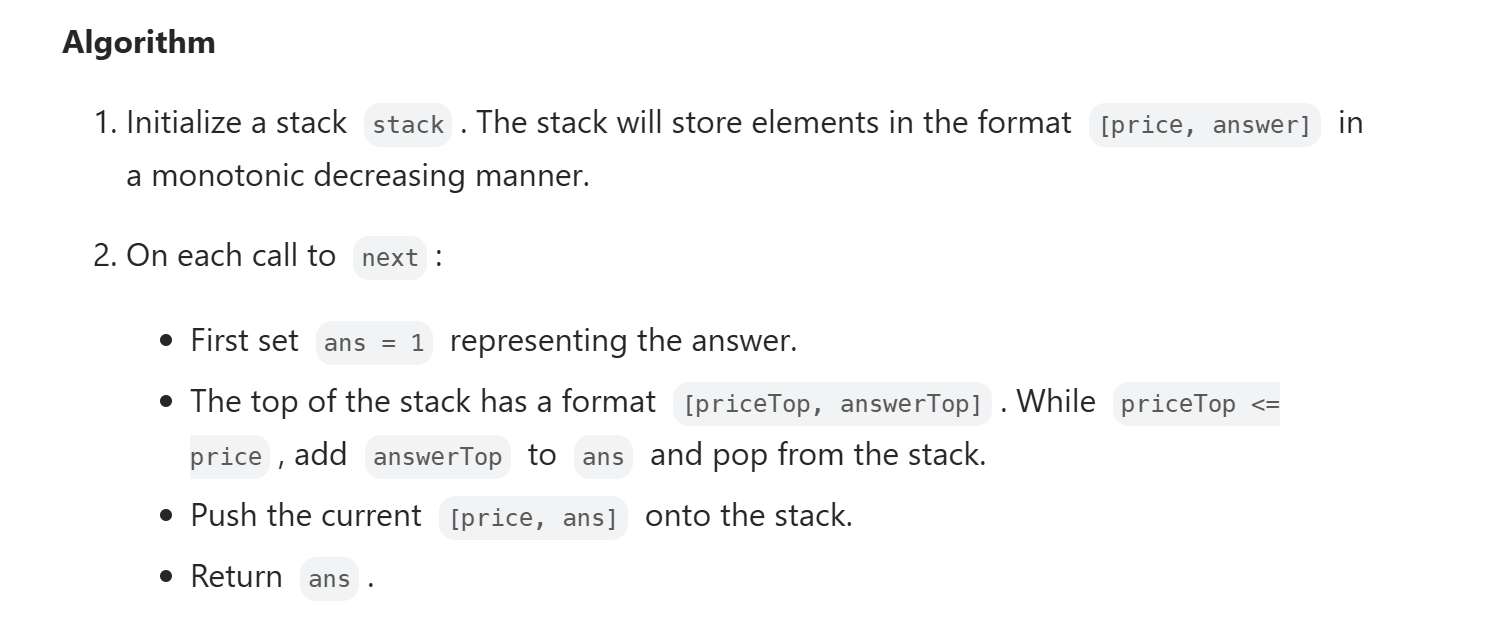

In [69]:
class StockSpanner:
    def __init__(self):
        self.stack = []

    def next(self, price):
        ans = 1
        while self.stack and self.stack[-1][0] <= price:
            ans += self.stack.pop()[1]
        self.stack.append([price , ans])
        return ans

# Trees and Graphs

Trees and graphs are abstract data structures that show up everywhere in both the physical world and software world. 

A **node** is an abstract data type with two things, first a node stores data. This data can be whatever you want, an integer a boolean, a hash map, a custom object. Second a node stores pointers to other nodes.

A **graph** is any collection of nodes and their pointers to other nodes. In fact linked lists and trees are both types of graphs.

Even though trees are a type of graph , trees and graphs are considered different topics. 

The nodes of a graph are also called **vertices** and the pointers that connect them are called **edges**. In graphical representations, nodes/vertices are usually represented with circles and the edges are line/arrows that connect the circles.


## Trees

Like a linked list, a **tree** is a type of graph. There are multiple kinds of trees in this course we focus on **binary trees**.

Recall that the start of a linked list was called the head. The start of a binary tree is called the **root**. In a linked list, a node's pointer points to the next node. In a tree a node has pointers to its **children**. If a node A is pointing to a node B then B is a child of A. A is the *parent* of B. 

The root is the only node that has no parent. A node cannot have more than one parent.

In a Binary tree all nodes have a **maximum of two children**. These children are referred to as left child and right child.


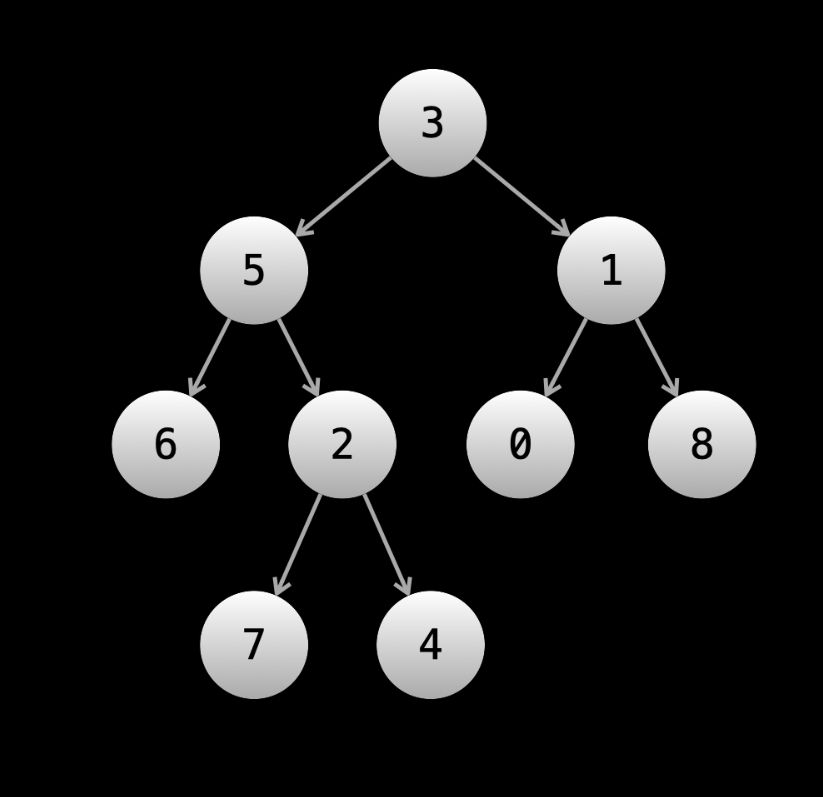


Trees are implemented all around us in real life, file systems, organizational charts. The important characteristics of the company that makes it a tree are that each person only has 1 manager (parent), and the entire tree is connected (if you start at anyone and continuously trace their managers, you will always end up at the CEO).

#### Tree Terminology

The **root** node is at the top of the tree. Every node in the tree is accessible starting from the root node. In most tree questions the root of the tree will be given as the input, just like in linked lists how the head is given.

If a node has no children it is called the **leaf** node The leaf nodes are the leaves of the tree.

The **depth** of a node is how far it is from the root node. The root has a depth of 0. 

A **subtree** of a tree is a node and all its descendents. You can take any given node and treat it as its own tree, **Trees are recursive* This allows you to solve problems in a recursive manner, KEY.

In [1]:
class TreeNode:
    def __init__(self, val, left, right):
        self.val = val
        self.left = left
        self.right = right


In binary tree problems you will be given a reference to the roor of a binary tree as the input. You can access the root's left subtree with root.left and ... right. Like wihth linked lists each node will also carrya value val as data. In a linked list the tail(last node) has its next pointer as null. In a binary tree if a node does not have a left child then node.left will be null. Remember if both children are null then the node is a leaf.

### Binary Trees - DFS

Tree traversal is how we access elements of a tree and is thus mandatory for solving tree problems. 

We start at the root and traverse by using child pointers .left and .right. When traversing linked lists, we usually do it iteratively. With binary trees we usually do it recursively. 

There are two main typed os tree traverals. The first is called **depth-first search DFS**. For binary trees there are three ways to perform DFS (**preorder, inorder and postorder**). The other main type of traversal is called **breadth-first search BFS**.

#### Depth first search 

Recall that the depth of a node is its distance from the root. In a DFS, we prioritize depth by traversing as far down the tree as possible in one direction. Until reaching a leaf node before considering the other direction. For example, let's say we choose left as our priority direction. We move exclusively with node.left until the left subtree has been fully explored. Then we explore the right subtree. Trees are names as such because they represent real-life trees the paths of binary trees can be though of as branches growing from the root. 

Because we need ot backtrack up the tree after reaching the end of a branch, DFS is typically implemented using recursion, although it is also sometimes done iteratively using a stack. here is a simple example of recursive DFS.

Each call to dfs(node) is visiting that node.

In [2]:
def dfs(node):
    if node == None:
        return

    dfs(node.left)  # we go down all the left nodes until we hit null  # we are still at the function call of the previous node then we call the right
    dfs(node.right) 
    return

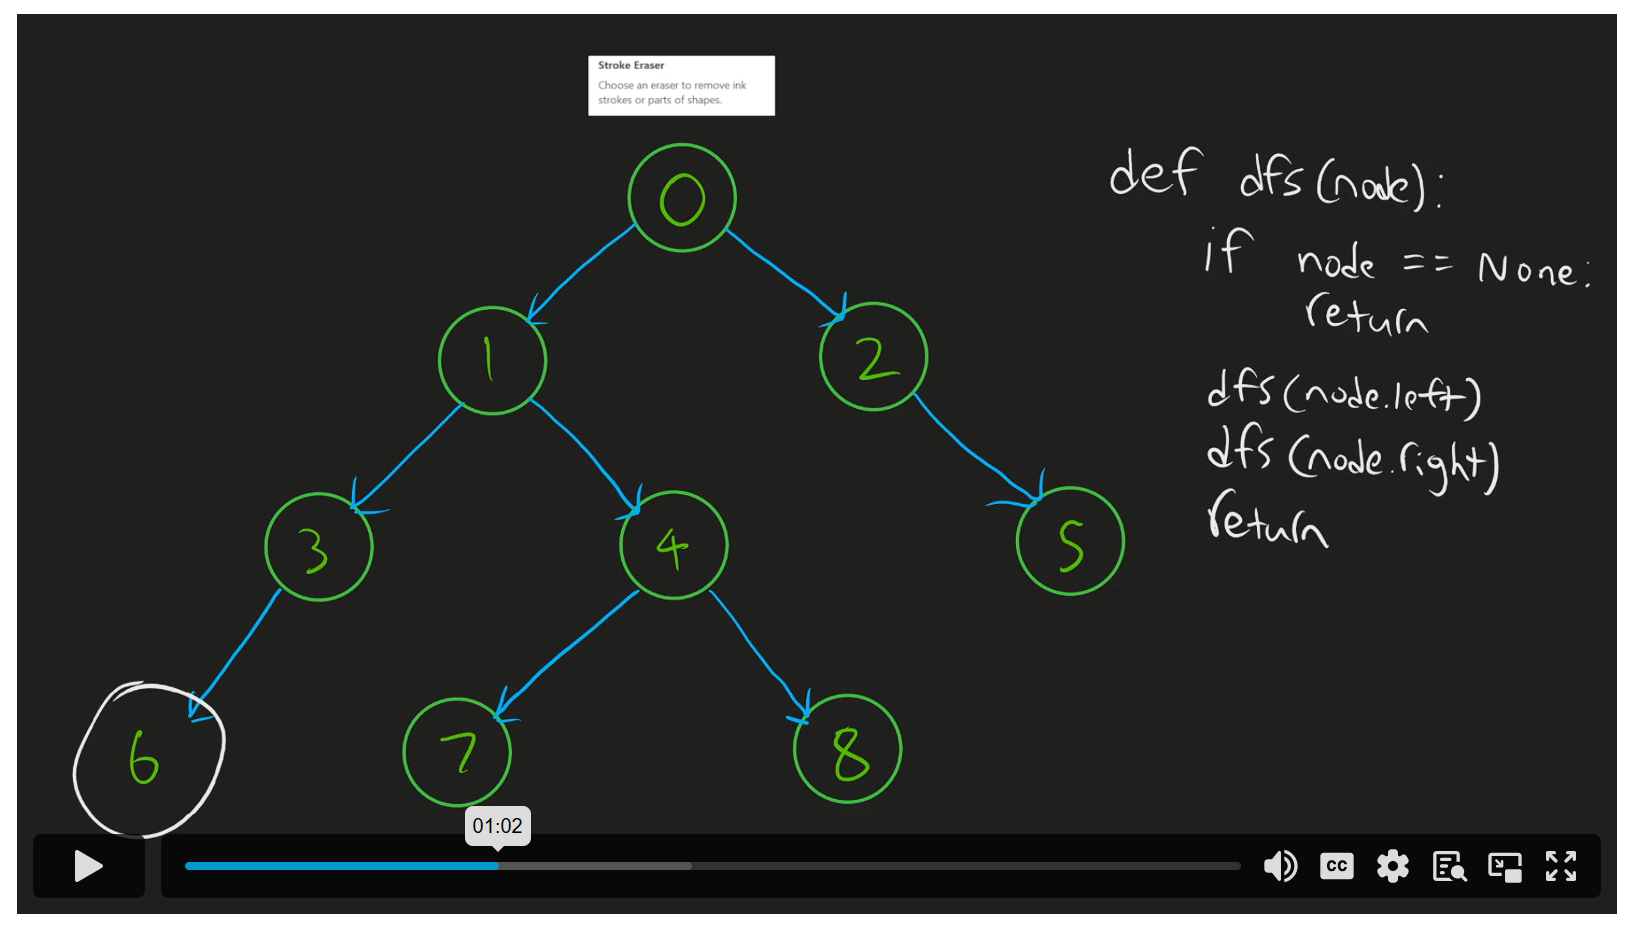

when we call the dfs on the root node we go down the left nodes first until we get to three we call dfs on 6 and it is None so we return and go down the right node which then is none so we return and we are completely done for the 3 call. The call from one then returns and we go down right to four where we go left to 7 then both left and right child are null so we return then we call right child to eight which has null children and returns, then we have done 4 as we have done both left and right call. Then left call of root , 1 is done so we go to right child.

Many calls to dfs exist simultaneously with their own versions of nodes.

The structure of dfs is very similar across all problems
1) handle the base case. Usually an empty tree node = null is the base case
2) Do some logic for the current node
3)  Recursively call on the current node's children
4) return the answer


The most important thing to understand when it comes ot binary tree solving problems is that each function call solves and returns the answer to the original problem as if the subtree rooted at the current node was the input. The logic that will be done at each call will depend ont he problem.

There are three types of dfs, each of the three differs only in the order that they execute steps 2/3.

#### Preorder traversal

In preorder traversal, logic is done on the current node before moving to the children. let's say that we wanted to just print the value of each node in the tree to the console. In that case at any given node, we would print the current node's value, then recursively call the left child then recursively call the right child.~

In [3]:
def preorder_dfs(node):
    if not node:
        return

    print(node.val)
    preorder_dfs(node.left)
    preorder_dfs(node.right)
    return

Running the above code on the examle tree we woudl see the nodes printed in this order 0,1,3,4,6,2,5

Because the logic (printing) is done immediately at the start of each function call, preorder handles nodes in the same order that the function calls happen.

#### Inorder Traversal

For inorder traversal, we first recursively call the left child, then perform logic (print in this case) on the current node, and then recursively call the right child. This means no logic will be done until we reach a node without a child since calling on the left child takes priority over performin logic.

In [4]:
def inorder_dfs(node):
    if not node:
        return

    inorder_dfs(node.left)
    print(node.val)
    inorder_dfs(node.right)
    return

Running the above code on the example tree, we would see the nodes printed in this order: 3, 1, 4, 6, 0, 2, 5.
#Notice that for any given node, its value is not printed until all values in the left subtree are printed, and values in its right subtree are not printed until after that.

#### Postorder traversal

In postorder traversal, we recursively call on the children first and then on the current node. This means no logic will be done until we reach a leaf node since calling on teh children takes priority over performing logic. In a postorder traversal, the root is the last node where logic is done. 

In [5]:
def postorder_dfs(node):
    if not node:
        return

    postorder_dfs(node.left)
    postorder_dfs(node.right)
    print(node.val)
    return

Running the above code on the example tree, we would see the nodes printed in this order: 3, 6, 4, 1, 5, 2, 0.

Notice that for any given node, no values in its right subtree are printed until all values in its left subtree are printed, and its own value is not printed until after that.

The name of each traversal is describing when the current node's logic is performed.

Pre -> before children

In -> in the middle of children

Post -> after children

In [6]:
class TreeNode:
    def __init__(self, val):
        self.val = val
        self.left = None
        self.right = None

"""
The following code builds a tree that looks like:
    0
  /   \
 1     2
"""

root = TreeNode(0)
one = TreeNode(1)
two = TreeNode(2)

root.left = one
root.right = two

print(root.left.val)
print(root.right.val)

1
2


### Solving problems with DFS

If you're worried about needing to know three different types of DFS, don't worry. If you're using recursion (which you should be), then switching between the three types is trivial.
In many problems the type of DFS used doesn't even matter it's just important that all nodes are visited. Knowing the differences beteween the three types of DFS is mostly good for trivia.

### Example 1: 104. Maximum Depth of Binary Tree

Given the root of a binary tree, find the length of the longest path from the root to a leaf.

In [7]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left # note not value but node number
#         self.right = right

class Solution:
    def maxDepth(self, root) -> int:
        if not root:
            return 0
        
        left = self.maxDepth(root.left)
        right = self.maxDepth(root.right)
        return max(left, right) + 1

A  relaly important concept regarding recursion is that each function call stores its own variables. Because we are calling the function for each node, that means every node has its own unique values of left and right.When we get to the node labelled 6, there are actually 4 different values of left simultaneously.

Note iin the solution above this is postorder traversal because the logic for the current node happens after the call. All three types of DFS can be implemented iteratively but postorde and inorder are more complicated to implement than preorder (which is very easy). As we mentioned earlier for most problems, the type of DFS doesn't matter, so we'll take a look at a preorder DFS implemented iteratively. To implement DFS iteratively we need to use a stack. We don't have the return values to store the depths, so we will instead need to associate the current depth with each node on the stack. The method for pairing the values will depend on the language you are using.

In [9]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def maxDepth(self, root) -> int:
        if not root:
            return 0
        
        stack = [(root, 1)]
        ans = 0
        
        while stack:
            node, depth = stack.pop()
            ans = max(ans, depth)
            if node.left:
                stack.append((node.left, depth + 1))
            if node.right:
                stack.append((node.right, depth + 1))
        
        return ans

The time and space complexity of tree questions is usually straightforward. The time complexity is almost always 
O
(
n
)
O(n), where 
n
n is the total number of nodes, because each node is only visited once, and at each node, 
O
(
1
)
O(1) work is done. If more than 
O
(
1
)
O(1) work is done at each node, let's say 
O
(
k
)
O(k) work, then the time complexity will be 
O
(
n
⋅
k
)
O(n⋅k).



Important note regarding iterative implementations: in the code, we are adding node.left before node.right. Popping from a stack removes the most recently added element, thus we are actually visiting the right subtree first in the above code. In the recursive implementations, we visit the left subtree first. This difference is irrelevant in this problem because the only thing that matters is that we visit all nodes, regardless of order. However, it is still good to understand that when working iteratively, the visit order is opposite the insertion order.

#### Example 2: 112. Path Sum

Given the root of a binary tree and an integer targetSum, return true if there exists a path from the root to a leaf such that the sum of the nodes on the path is equal to targetSum, and return false otherwise.

In [12]:
class Solution:
    def hasPathSum(self, root, targetSum: int) -> bool:
        def dfs(node, curr):
            if not node:
                return False
            
            # if both children are null, then the node is a leaf
            if node.left == None and node.right == None:
                return (curr + node.val) == targetSum
            
            curr += node.val
            left = dfs(node.left, curr)
            right = dfs(node.right, curr)
            return left or right
        
        return dfs(root, 0)

#### Example 3: 1448. Count Good Nodes in Binary Tree

Given the root of a binary tree, find the number of nodes that are good. A node is good if the path between the root and the node has no nodes with a greater value.

In [13]:
class Solution:
    def goodNodes(self, root: TreeNode) -> int:
        def dfs(node, max_so_far):
            if not node:
                return 0
            
            left = dfs(node.left, max(max_so_far, node.val))
            right = dfs(node.right, max(max_so_far, node.val))
            ans = left + right
            if node.val >= max_so_far:
                ans += 1

            return ans

        return dfs(root, float("-inf"))

#### Example 4: 100. Same Tree

Given the roots of two binary trees p and q, check if they are the same tree. Two binary trees are the same tree if they are structurally identical and the nodes have the same values.

In [14]:
class Solution:
    def isSameTree(self, p: TreeNode, q: TreeNode) -> bool:
        if p == None and q == None:
            return True
        
        if p == None or q == None:
            return False
        
        if p.val != q.val:
            return False
        
        left = self.isSameTree(p.left, q.left)
        right = self.isSameTree(p.right, q.right)
        return left and right